# =========================================
# TECH CHALLENGE - FASE 1
# Pós Tech Data Analytics
# Grupo: 12
# =========================================

Tema:

## **Impacto da Logística na Satisfação do Cliente  e Crescimento do Marketplace**

# 0 - Configuração do Ambiente Analítico

Antes do início das análises, foi realizada a preparação do ambiente utilizado no desenvolvimento deste projeto.

Nesta etapa foram definidas as configurações necessárias para importação dos dados, tratamento das informações, construção das análises e geração das visualizações apresentadas ao longo do estudo.

A organização prévia do ambiente contribuiu para a padronização das análises e para a reprodutibilidade dos resultados obtidos pela equipe.


## 0.1 Importação das Bibliotecas

Foram importadas as bibliotecas necessárias para leitura, tratamento, análise e visualização dos dados utilizados neste projeto.

In [100]:
# ============================================================
# CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL base dos dados no GitHub
URL_BASE = "https://raw.githubusercontent.com/erikacb1982/fiap-tech-challenge-olist/main/dados"

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


In [101]:
from pathlib import Path
import subprocess

REPO = "fiap-tech-challenge-olist"

if not Path(REPO).exists():
    subprocess.run(
        ["git", "clone",
         "https://github.com/erikacb1982/fiap-tech-challenge-olist"],
        check=True
    )

print("Repositório disponível.")

Repositório disponível.


In [102]:
# ============================================================
# Carregamento dos datasets
# ============================================================

orders_df = pd.read_csv(f"{URL_BASE}/olist_orders_dataset.csv")
customers_df = pd.read_csv(f"{URL_BASE}/olist_customers_dataset.csv")
products_df = pd.read_csv(f"{URL_BASE}/olist_products_dataset.csv")
reviews_df = pd.read_csv(f"{URL_BASE}/olist_order_reviews_dataset.csv")
order_items_df = pd.read_csv(f"{URL_BASE}/olist_order_items_dataset.csv")
payments_df = pd.read_csv(f"{URL_BASE}/olist_order_payments_dataset.csv")
sellers_df = pd.read_csv(f"{URL_BASE}/olist_sellers_dataset.csv")
geolocation_df = pd.read_csv(f"{URL_BASE}/olist_geolocation_dataset.csv")

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


In [103]:
# ============================================================
# Padronização dos nomes das bases
# ============================================================

customers = customers_df
orders = orders_df
products = products_df
reviews = reviews_df
order_items = order_items_df
payments = payments_df
sellers = sellers_df
geolocation = geolocation_df

print("Bases padronizadas com sucesso.")

Bases padronizadas com sucesso.


In [104]:
# ============================================================
# 0.1 - Instalação de Dependências
# Executar apenas na primeira utilização do notebook
# ou quando estiver rodando em uma nova máquina.
# ============================================================

# Instala a biblioteca Seaborn utilizada nos gráficos.
%pip install seaborn

In [105]:
#0.1 - Importando Bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Ignorar avisos
import warnings
warnings.filterwarnings('ignore')

In [106]:
# ============================================================
# 0.1 - Importação das Bibliotecas
# Biblioteca: os
# ============================================================
# Objetivo:
# Permitir a interação do Python com arquivos e pastas
# utilizados pelo projeto.
#
# Principais utilizações:
# - Listar arquivos da pasta de dados;
# - Validar a existência de arquivos;
# - Apoiar verificações de estrutura do projeto.
#
# Resultado esperado:
# Disponibilizar funções para acesso e validação dos
# arquivos armazenados no repositório.
# ============================================================

# Biblioteca para interação com arquivos e diretórios.
import os


## 0.2 Configuração do Pandas

Foram definidas configurações de exibição para facilitar a exploração e validação das bases de dados ao longo do estudo.

In [107]:
# Mostrar todas as colunas
pd.set_option('display.max_columns', None)

# Mostrar mais linhas
pd.set_option('display.max_rows', 100)

# Ajustar largura da exibição
pd.set_option('display.width', None)

# Mostrar números com 2 casas decimais
pd.options.display.float_format = '{:.2f}'.format

## 0.3 Configurações de Visualização

Foram estabelecidos padrões visuais para os gráficos apresentados neste relatório, contribuindo para maior consistência na apresentação dos resultados.

In [108]:
# ============================================================
# 0.3 - Configurações de Visualização
# ============================================================
# Objetivo:
# Definir configurações visuais padrão que serão utilizadas
# em todos os gráficos do projeto.
#
# Essas configurações garantem:
# - Padronização visual;
# - Maior legibilidade;
# - Consistência entre análises;
# - Melhor experiência para o leitor.
# ============================================================

# ------------------------------------------------------------
# Define o estilo visual padrão dos gráficos
# ------------------------------------------------------------
# O estilo "ggplot" é inspirado na biblioteca de visualização
# do R e oferece:
#
# - Fundo mais limpo;
# - Grid discreto para facilitar leitura;
# - Melhor contraste visual;
# - Aparência profissional para análises exploratórias.
# ------------------------------------------------------------

plt.style.use('ggplot')

# ------------------------------------------------------------
# Define o tamanho padrão das figuras
# ------------------------------------------------------------
# figsize = (largura, altura)
#
# Nesse caso:
# - largura = 10 polegadas
# - altura = 5 polegadas
#
# Benefícios:
# - Evita gráficos muito pequenos;
# - Mantém proporção adequada para visualização;
# - Padroniza a aparência ao longo do notebook.
# ------------------------------------------------------------

plt.rcParams['figure.figsize'] = (10, 5)

In [109]:
cor_padrao = '#3E5F8A'

In [110]:
# ==========================================
# PALETA EXECUTIVA PADRÃO DO PROJETO
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

COR_PRINCIPAL = "#3E5F8A"    # Destaque principal
COR_SECUNDARIA = "#6E8FB8"   # Comparações
COR_APOIO = "#B7CBE3"        # Categorias secundárias

COR_POSITIVO = "#4E7D5A"     # Resultados positivos
COR_ATENCAO = "#D4A017"      # Alertas
COR_NEGATIVO = "#B54747"     # Problemas críticos

COR_NEUTRO = "#6B7280"       # Informações auxiliares
COR_FUNDO = "#F8F9FA"        # Fundo dos gráficos

PALETA_EXECUTIVA = [
    COR_PRINCIPAL,
    COR_SECUNDARIA,
    COR_APOIO,
    COR_POSITIVO,
    COR_ATENCAO,
    COR_NEUTRO
]

## 0.4 - Criação de Funções de Apoio à Análise

**Problema de Negócio**

Ao longo da exploração dos dados, atividades como validação de bases, análise de variáveis, cálculo de indicadores e verificação de qualidade são executadas diversas vezes. A repetição dessas tarefas aumenta o volume de código, dificulta a manutenção do notebook e pode gerar diferenças na forma como as análises são realizadas.

**Objetivo**

Desenvolver funções reutilizáveis para automatizar tarefas recorrentes de exploração e análise dos dados, promovendo maior organização e consistência durante o desenvolvimento do projeto.

**Hipótese**

A utilização de funções padronizadas reduzirá a repetição de código, facilitará a manutenção do notebook e contribuirá para a execução mais consistente das análises.

**Decisão Apoiada**

Estabelecer uma estrutura de apoio que facilite a exploração inicial dos dados e ofereça suporte às etapas posteriores de preparação, análise e validação das informações.


In [111]:
#Padronizando Describe
def describe_pt(coluna, *args, **kwargs):

    return coluna.describe(*args, **kwargs).rename({
        'count': 'quantidade',
        'mean': 'média',
        'std': 'desvio_padrão',
        'min': 'mínimo',
        '25%': '1_quartil',
        '50%': 'mediana',
        '75%': '3_quartil',
        'max': 'máximo'
    })


In [112]:
# ============================================================
# Função para corrigir o símbolo R$ em textos Markdown
# ============================================================

def corrigir_real(texto):
    """
    Substitui R$ por R\$ para evitar problemas
    de renderização no Markdown do Colab/Jupyter.
    """

    return texto.replace('R$', 'R\\$')

In [113]:
# ============================================================
# Função padrão de tabelas do projeto
# Executar apenas uma vez no notebook
# ============================================================

def tabela_executiva(df):

    return (
        df.style

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#3E5F8A"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #B7CBE3")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #B7CBE3"),
                    ("color", "#6B7280")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F8F9FA")
                ]
            },
            {
                "selector": "tbody tr:nth-child(odd)",
                "props": [
                    ("background-color", "#FFFFFF")
                ]
            }
        ])

        .set_properties(**{
            "text-align": "center"
        })

        .hide(axis="index")
    )

## 0.5 - Organização e Validação dos Arquivos de Dados

**Problema de Negócio**

A utilização de arquivos incorretos, incompletos ou indisponíveis pode comprometer as etapas de importação e preparação dos dados. Antes do carregamento das bases, é necessário confirmar que todos os arquivos esperados estão disponíveis e corretamente identificados.

**Objetivo**

Organizar e validar a estrutura dos arquivos utilizados no projeto, verificando sua disponibilidade e identificação antes da etapa de importação dos dados.

**Hipótese**

A validação prévia dos arquivos facilitará o processo de carga das bases e permitirá identificar eventuais inconsistências antes do início das análises.

**Decisão Apoiada**

Confirmar que as etapas subsequentes serão executadas utilizando os arquivos previstos para o desenvolvimento do estudo.


### 0.5.1 - Definição dos Caminhos de Acesso

Foi definido o diretório principal do projeto no Google Drive, que será utilizado como referência para localização e acesso aos arquivos necessários para o desenvolvimento das análises.


In [114]:
# ==========================================================
# 0.5.1 Configuração do Caminho dos Dados
# ==========================================================
# Objetivo:
# Definir o local onde estão armazenados os arquivos
# de dados utilizados no projeto.
#
# Decisão que apoia:
# Permitir que o notebook execute em qualquer máquina,
# utilizando os arquivos disponíveis no repositório GitHub,
# sem dependência de Google Drive ou caminhos locais.
# ==========================================================

# Importa a classe Path para trabalhar com caminhos de
# arquivos e pastas de forma compatível com diferentes
# sistemas operacionais.
from pathlib import Path

# Define a pasta onde estão armazenados os arquivos
# de dados do projeto.
CAMINHO_DADOS = Path("fiap-tech-challenge-olist/dados")

# Exibe o caminho configurado para validação.
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [115]:
# Exibe o valor atual armazenado na variável.
print(CAMINHO_DADOS)


fiap-tech-challenge-olist/dados


### 0.5.2 - Identificação dos Arquivos de Dados

**Objetivo**

Listar os arquivos disponíveis no diretório do projeto antes da etapa de importação dos dados.

**Decisão Apoiada**

Verificar se os arquivos esperados estão disponíveis e acessíveis para utilização nas etapas subsequentes da análise.

**Pergunta**

Quais arquivos estão disponíveis na pasta do projeto?


In [116]:
# Exibe o valor atual da variável.
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [117]:
# Importa a biblioteca para listar arquivos e pastas.
import os

# Lista todos os arquivos existentes na pasta de dados.
arquivos = os.listdir(CAMINHO_DADOS)

# Exibe cada arquivo encontrado.
for arquivo in arquivos:
    print(arquivo)

olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_order_reviews_dataset.csv
olist_sellers_dataset.csv
olist_products_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
product_category_name_translation.csv
.gitkeep
olist_orders_dataset.csv


### 0.5.3 - Validação dos Arquivos Disponíveis

Após a identificação dos arquivos presentes no diretório do projeto, foi realizada a conferência dos arquivos esperados para verificar se todas as bases necessárias estavam disponíveis para importação.


### 0.5.4 - Validação da Importação

Após a importação das bases, foi realizada uma verificação inicial para confirmar que os arquivos foram carregados corretamente no ambiente de análise.



In [118]:
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [119]:
# ==========================================================
# 0.5.4 Validação da Importação
# ==========================================================

bases_importadas = {
    "customers_df": customers_df,
    "orders_df": orders_df,
    "order_items_df": order_items_df,
    "products_df": products_df,
    "reviews_df": reviews_df,
    "payments_df": payments_df,
    "sellers_df": sellers_df,
    "geolocation_df": geolocation_df
}

for nome, base in bases_importadas.items():
    print(f"✅ {nome}: {base.shape[0]:,} linhas e {base.shape[1]} colunas")

✅ customers_df: 99,441 linhas e 5 colunas
✅ orders_df: 99,441 linhas e 8 colunas
✅ order_items_df: 112,650 linhas e 7 colunas
✅ products_df: 32,951 linhas e 9 colunas
✅ reviews_df: 99,224 linhas e 7 colunas
✅ payments_df: 103,886 linhas e 5 colunas
✅ sellers_df: 3,095 linhas e 4 colunas
✅ geolocation_df: 1,000,163 linhas e 5 colunas


In [120]:
# ==========================================================
# Validação da Importação
# ==========================================================
# Exibe a quantidade de linhas e colunas de cada base
# importada para confirmar o carregamento dos arquivos.
# ==========================================================

print("customers_df:", customers_df.shape)
print("orders_df:", orders_df.shape)
print("order_items_df:", order_items_df.shape)
print("products_df:", products_df.shape)
print("reviews_df:", reviews_df.shape)
print("payments_df:", payments_df.shape)
print("sellers_df:", sellers_df.shape)
print("geolocation_df:", geolocation_df.shape)

customers_df: (99441, 5)
orders_df: (99441, 8)
order_items_df: (112650, 7)
products_df: (32951, 9)
reviews_df: (99224, 7)
payments_df: (103886, 5)
sellers_df: (3095, 4)
geolocation_df: (1000163, 5)


# 1 - Introdução e Contexto de Negócio

O comércio eletrônico ampliou significativamente sua participação no varejo brasileiro nos últimos anos, gerando grandes volumes de dados sobre pedidos, clientes, produtos, pagamentos, logística e avaliações de consumidores.

Nesse contexto, compreender os fatores associados à satisfação dos clientes tornou-se um tema relevante para empresas que atuam em marketplaces, uma vez que a experiência de compra pode influenciar a recorrência de vendas, a reputação da plataforma e o desempenho do negócio.

A Olist atua conectando pequenos e médios vendedores a diferentes marketplaces, concentrando informações que permitem analisar tanto aspectos operacionais quanto o comportamento dos consumidores ao longo da jornada de compra.

Este estudo utiliza o Brazilian E-Commerce Public Dataset by Olist, que reúne transações realizadas entre 2016 e 2018. A partir da integração e análise dessas bases, serão explorados aspectos relacionados ao desempenho comercial, à operação logística e às avaliações dos clientes.

As seções seguintes apresentam o contexto da empresa, o problema de negócio, as perguntas norteadoras e os objetivos definidos para o desenvolvimento do projeto.


## 1.1 - Contexto do Negócio

A Olist é uma empresa brasileira de tecnologia fundada em 2015 que atua conectando pequenos e médios lojistas a diferentes canais de venda online. Por meio de sua plataforma, vendedores podem comercializar produtos em marketplaces e ampliar seu alcance para consumidores em todo o país (OLIST, 2025).

Seu modelo de atuação reúne vendedores, consumidores e marketplaces em um mesmo ambiente de negócios. À medida que novos lojistas ingressam na plataforma, aumenta a oferta de produtos disponíveis aos consumidores, ampliando o volume de transações realizadas e a relevância da operação (OLIST, 2025).

Em ambientes digitais, a experiência do cliente tornou-se um fator estratégico para a competitividade das plataformas de comércio eletrônico. Diferentemente do varejo físico, em que o consumidor tem contato imediato com o produto, a jornada digital depende da eficiência de diversos processos operacionais, incluindo aprovação do pedido, processamento da compra, expedição e entrega. Dessa forma, a percepção de qualidade do serviço está diretamente associada à capacidade da operação de atender às expectativas dos consumidores (KOTLER; KELLER, 2012).

Nesse cenário, a logística assume papel relevante ao conectar a operação dos vendedores à experiência percebida pelos clientes. O cumprimento dos prazos de entrega, a previsibilidade da operação e a redução de falhas ao longo da jornada de compra contribuem para fortalecer a confiança dos consumidores e a percepção de qualidade do serviço. Por outro lado, atrasos e inconsistências operacionais podem comprometer a experiência de compra e impactar negativamente a reputação dos participantes do ecossistema (CHOPRA; MEINDL, 2016).

Considerando as características desse modelo de negócio, torna-se relevante compreender como fatores relacionados ao desempenho comercial, à operação logística e à satisfação dos clientes se relacionam dentro da plataforma. Essa compreensão fornece subsídios para avaliar o comportamento do marketplace e identificar aspectos associados à experiência de compra observada na base de dados analisada.




## 1.2 - Evolução da Empresa

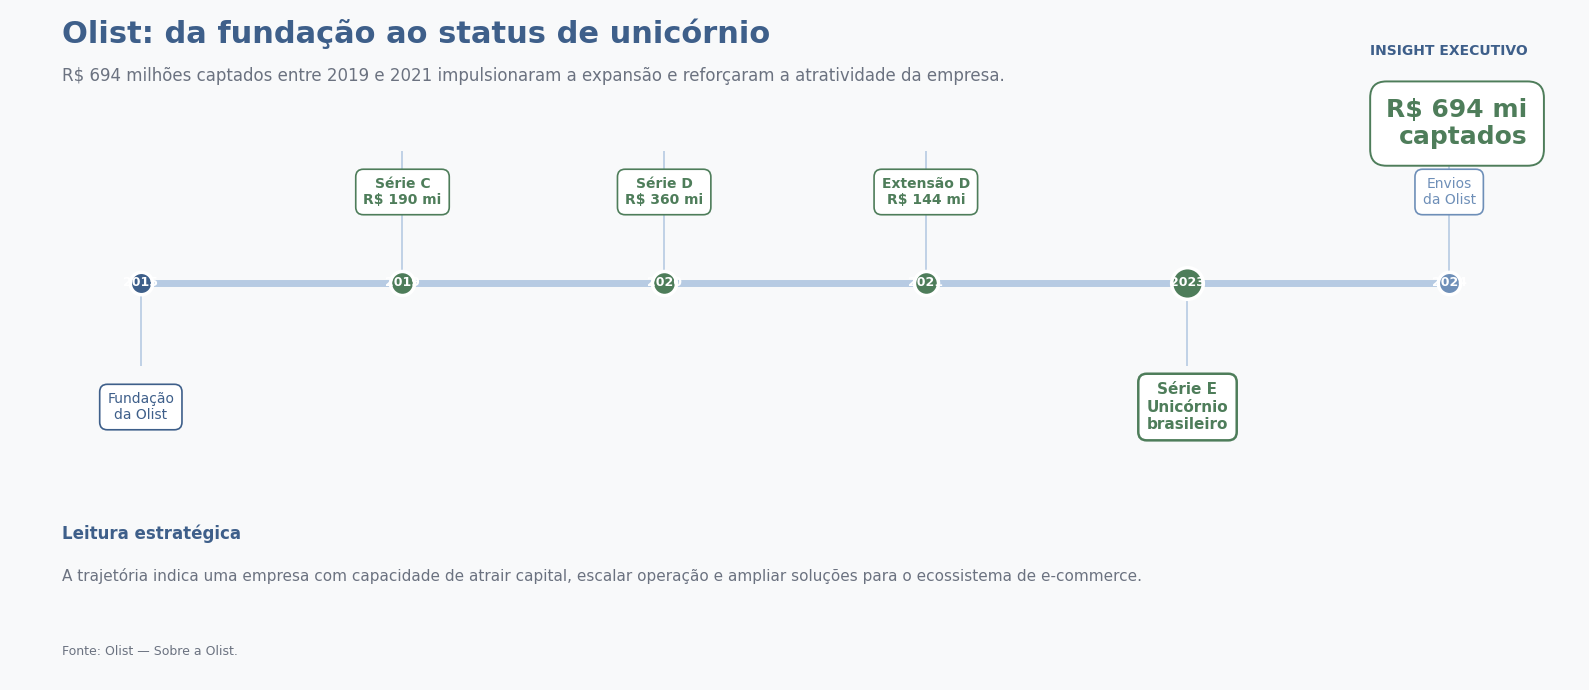

In [121]:
import matplotlib.pyplot as plt

#Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# Dados a partir da fundação da Olist
#criação de dicionário, com 3 informações: ano, titulo e tipo
#tipo para que eventos diferentes tenham aparências diferentes. Classificação
eventos = [
    {"ano": "2015", "titulo": "Fundação\nda Olist", "tipo": "base"},
    {"ano": "2019", "titulo": "Série C\nR$ 190 mi", "tipo": "capital"},
    {"ano": "2020", "titulo": "Série D\nR$ 360 mi", "tipo": "capital"},
    {"ano": "2021", "titulo": "Extensão D\nR$ 144 mi", "tipo": "capital"},
    {"ano": "2023", "titulo": "Série E\nUnicórnio\nbrasileiro", "tipo": "destaque"},
    {"ano": "2024", "titulo": "Envios\nda Olist", "tipo": "expansao"}
]

# Espaçamento visual igual para evitar sobreposição

x = list(range(len(eventos)))
# Conte quantos eventos existem - (len(eventos)
# Crie uma sequência de posições para eles(range(...)
# Transforme essa sequência em uma lista para armazenar na variável x

fig, ax = plt.subplots(figsize=(16, 7), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

# =========================
# 1. TÍTULO EXECUTIVO
# =========================

ax.text(
    -0.3, 2.25,
    "Olist: da fundação ao status de unicórnio",
    fontsize=22,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left"
)

ax.text(
    -0.3, 2.02,
    "R$ 694 milhões captados entre 2019 e 2021 impulsionaram a expansão e reforçaram a atratividade da empresa.",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# =========================
# 2. CARD DE INSIGHT
# =========================

ax.text(
    5.3, 2.18,
    "INSIGHT EXECUTIVO",
    fontsize=10,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="right"
)

ax.text(
    5.3, 1.92,
    "R$ 694 mi\ncaptados",
    fontsize=18,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.65",
        facecolor=BRANCO,
        edgecolor=VERDE_SOFISTICADO,
        linewidth=1.4
    )
)

# =========================
# 3. LINHA PRINCIPAL
# =========================

ax.hlines(
    y=0.8,
    xmin=0,
    xmax=len(eventos) - 1,
    color=AZUL_CLARO,
    linewidth=5,
    zorder=1
)

# =========================
# 4. EVENTOS
# =========================

for i, evento in enumerate(eventos):
    tipo = evento["tipo"]

    if tipo == "base":
        cor = AZUL_EXECUTIVO
        tamanho = 260
        y_card = 0.05
    elif tipo == "capital":
        cor = VERDE_SOFISTICADO
        tamanho = 300
        y_card = 1.35
    elif tipo == "destaque":
        cor = VERDE_SOFISTICADO
        tamanho = 520
        y_card = 0.05
    else:
        cor = AZUL_MEDIO
        tamanho = 260
        y_card = 1.35

    # Ponto
    ax.scatter(
        i,
        0.8,
        s=tamanho,
        color=cor,
        edgecolor=BRANCO,
        linewidth=2.5,
        zorder=3
    )

    # Ano acima do ponto
    ax.text(
        i,
        0.8,
        evento["ano"],
        fontsize=9,
        fontweight="bold",
        color=BRANCO,
        ha="center",
        va="center",
        zorder=4
    )

    # Conector
    ax.vlines(
        i,
        ymin=min(0.8, y_card + 0.25),
        ymax=max(0.8, y_card + 0.25),
        color=AZUL_CLARO,
        linewidth=1.2,
        zorder=1
    )

    # Card do evento
    ax.text(
        i,
        y_card,
        evento["titulo"],
        fontsize=10 if tipo != "destaque" else 11,
        fontweight="bold" if tipo in ["capital", "destaque"] else "normal",
        color=cor,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=BRANCO,
            edgecolor=cor,
            linewidth=1.2 if tipo != "destaque" else 1.8
        ),
        zorder=5
    )

# =========================
# 5. FAIXA DE INTERPRETAÇÃO
# =========================

ax.text(
    -0.3, -0.75,
    "Leitura estratégica",
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left"
)

ax.text(
    -0.3, -1.00,
    "A trajetória indica uma empresa com capacidade de atrair capital, escalar operação e ampliar soluções para o ecossistema de e-commerce.",
    fontsize=11,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# Fonte
ax.text(
    -0.3, -1.45,
    "Fonte: Olist — Sobre a Olist.",
    fontsize=9,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# =========================
# 6. LIMPEZA VISUAL
# =========================

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-1.6, 2.45)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    "timeline_olist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "timeline_olist.pdf",
    bbox_inches="tight"
)


plt.show()

## 1.3 - Problema de Negócio

A satisfação dos clientes é um dos principais indicadores da experiência de compra em operações de comércio eletrônico. No entanto, diferentes fatores podem influenciar a percepção dos consumidores, incluindo aspectos relacionados à logística de entrega, à experiência vivenciada durante a compra e às características regionais da operação.

Embora a Olist disponha de informações sobre pedidos, entregas, avaliações e localização dos clientes, não é possível identificar apenas pela observação dos dados quais fatores apresentam maior relação com a satisfação observada na plataforma.

Dessa forma, este estudo busca compreender como o prazo de entrega, a percepção da experiência de compra e a região de atendimento se relacionam com as avaliações atribuídas pelos clientes.




## 1.4 - Perguntas Norteadoras

**1. De que forma o prazo de entrega impacta a satisfação dos clientes?**

O prazo de entrega é um dos componentes da experiência de compra em ambientes digitais. Entregas realizadas dentro ou antes do prazo podem contribuir para avaliações mais positivas, enquanto atrasos podem estar associados a níveis mais elevados de insatisfação.

**2. Como os clientes percebem sua experiência de compra no e-commerce?**

A percepção dos clientes pode ser analisada a partir da distribuição das avaliações e da classificação entre promotores, neutros e detratores, permitindo compreender diferentes padrões de satisfação observados na base de dados.

**3. A região de entrega influencia a satisfação dos clientes e a distribuição entre promotores, neutros e detratores?**

Diferenças regionais relacionadas à operação logística e ao atendimento podem influenciar a experiência dos consumidores. A comparação entre regiões permite avaliar se existem variações relevantes nos níveis de satisfação observados.


## 1.5 - Objetivo do Projeto

Este projeto tem como objetivo analisar dados do marketplace Olist para compreender fatores associados à satisfação dos clientes e à experiência de compra observada na plataforma.

A análise será conduzida a partir de informações sobre pedidos, entregas, avaliações e localização dos clientes, buscando investigar a relação entre prazo de entrega, percepção da experiência de compra e diferenças regionais de satisfação.

Os resultados obtidos serão utilizados para responder às perguntas norteadoras definidas para o estudo e compreender como esses fatores se manifestam nos dados disponíveis.



# 2 - Entendimento e Preparação dos Dados

Após a definição do problema de negócio, das perguntas norteadoras e das hipóteses da análise, foi realizada a exploração das bases de dados disponibilizadas pela Olist.

Nesta etapa foram executadas atividades de leitura, organização e padronização dos conjuntos de dados, além da análise dos relacionamentos entre as tabelas que compõem o estudo.

O entendimento da estrutura das bases permitiu identificar a granularidade dos dados, compreender as relações entre as entidades e preparar as informações necessárias para as etapas subsequentes de análise.


### 2.1 - Visão Geral do Dataset

**Objetivo**

Apresentar as bases disponibilizadas pela Olist e identificar as principais informações disponíveis para análise.

**Pergunta**

Quais dados estão disponíveis e como eles podem contribuir para responder às perguntas norteadoras do projeto?






In [122]:
# ============================================================
# Visão Geral do Dataset Olist
# ============================================================
# Objetivo:
# Criar uma tabela executiva com a visão geral das bases
# utilizadas no projeto, apresentando:
# - nome da tabela;
# - descrição em linguagem de negócio;
# - quantidade de linhas;
# - quantidade de colunas;
# - granularidade de cada base.
#
# Resultado esperado:
# Apoiar o entendimento inicial do dataset e documentar
# a estrutura das bases antes das etapas de integração,
# tratamento e análise.
# ============================================================

# ============================================================
# 1. Criação do dicionário com as bases do projeto
# ============================================================

tabelas_dataset = {
    "customers": customers_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "products": products_df,
    "reviews": reviews_df,
    "payments": payments_df,
    "sellers": sellers_df,
    "geolocation": geolocation_df
}

# ============================================================
# 2. Criação da tabela de visão geral
# ============================================================

visao_geral_dataset = pd.DataFrame({
    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],

    "descrição": [
        "Informações dos clientes",
        "Informações dos pedidos",
        "Itens vendidos por pedido",
        "Catálogo de produtos",
        "Avaliações dos clientes",
        "Informações de pagamento",
        "Informações dos vendedores",
        "Coordenadas geográficas por CEP"
    ],

    "linhas": [
        customers_df.shape[0],
        orders_df.shape[0],
        order_items_df.shape[0],
        products_df.shape[0],
        reviews_df.shape[0],
        payments_df.shape[0],
        sellers_df.shape[0],
        geolocation_df.shape[0]
    ],

    "colunas": [
        customers_df.shape[1],
        orders_df.shape[1],
        order_items_df.shape[1],
        products_df.shape[1],
        reviews_df.shape[1],
        payments_df.shape[1],
        sellers_df.shape[1],
        geolocation_df.shape[1]
    ],

    "granularidade": [
        "1 linha = 1 cliente",
        "1 linha = 1 pedido",
        "1 linha = 1 item vendido",
        "1 linha = 1 produto",
        "1 linha = 1 avaliação",
        "1 linha = 1 pagamento",
        "1 linha = 1 vendedor",
        "1 linha = 1 localização por CEP"
    ]
})

# ============================================================
# 3. Formatação dos números no padrão brasileiro
# ============================================================

visao_geral_dataset["linhas"] = (
    visao_geral_dataset["linhas"]
    .apply(lambda x: f"{x:,.0f}".replace(",", "."))
)

visao_geral_dataset["colunas"] = (
    visao_geral_dataset["colunas"]
    .apply(lambda x: f"{x:,.0f}".replace(",", "."))
)

# ============================================================
# 4. Exibição da tabela no padrão visual executivo
# ============================================================

display(
    tabela_executiva(
        visao_geral_dataset
    )
)

tabela,descrição,linhas,colunas,granularidade
customers,Informações dos clientes,99.441,5,1 linha = 1 cliente
orders,Informações dos pedidos,99.441,8,1 linha = 1 pedido
order_items,Itens vendidos por pedido,112.650,7,1 linha = 1 item vendido
products,Catálogo de produtos,32.951,9,1 linha = 1 produto
reviews,Avaliações dos clientes,99.224,7,1 linha = 1 avaliação
payments,Informações de pagamento,103.886,5,1 linha = 1 pagamento
sellers,Informações dos vendedores,3.095,4,1 linha = 1 vendedor
geolocation,Coordenadas geográficas por CEP,1.000.163,5,1 linha = 1 localização por CEP


In [123]:
# 2.1 Tabela resumo do Dataset
# Objetivo: criar uma visão geral das bases utilizadas no projeto,
# mostrando volume, quantidade de colunas, descrição e granularidade.

resumo_bases = pd.DataFrame({
    'Tabela': [
        'customers', 'orders', 'order_items', 'products',
        'reviews', 'payments', 'sellers', 'geolocation'
    ],

    'Linhas': [
        customers_df.shape[0],
        orders_df.shape[0],
        order_items_df.shape[0],
        products_df.shape[0],
        reviews_df.shape[0],
        payments_df.shape[0],
        sellers_df.shape[0],
        geolocation_df.shape[0]
    ],

    'Colunas': [
        customers_df.shape[1],
        orders_df.shape[1],
        order_items_df.shape[1],
        products_df.shape[1],
        reviews_df.shape[1],
        payments_df.shape[1],
        sellers_df.shape[1],
        geolocation_df.shape[1]
    ],

    'Descrição': [
        'Informações dos clientes',
        'Informações dos pedidos',
        'Itens vendidos por pedido',
        'Catálogo de produtos',
        'Avaliações dos clientes',
        'Informações de pagamento',
        'Informações dos vendedores',
        'Coordenadas geográficas por CEP'
    ],

    'Granularidade': [
        '1 linha = 1 cliente',
        '1 linha = 1 pedido',
        '1 linha = 1 item vendido',
        '1 linha = 1 produto',
        '1 linha = 1 avaliação',
        '1 linha = 1 pagamento',
        '1 linha = 1 vendedor',
        '1 linha = 1 localização por CEP'
    ]
})

# Formata a coluna Linhas com separador de milhar no padrão brasileiro
resumo_bases['Linhas'] = resumo_bases['Linhas'].map(lambda x: f'{x:,.0f}'.replace(',', '.'))

# Formata a coluna Colunas como número inteiro
resumo_bases['Colunas'] = resumo_bases['Colunas'].map(lambda x: f'{x:.0f}')

# Aplica estilo visual executivo na tabela
tabela_estilizada = (
    resumo_bases.style
    .hide(axis='index')  # Remove o índice numérico da esquerda
    .set_caption("Estrutura e Volume das Bases do Dataset Olist")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#3E5F8A'),
                ('text-align', 'left')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3E5F8A'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #FFFFFF')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('background-color', '#F8F9FA'),
                ('color', '#333333'),
                ('border', '1px solid #D9D9D9'),
                ('padding', '8px')
            ]
        }
    ])
    .set_properties(
        subset=['Linhas', 'Colunas'],
        **{'text-align': 'right'}
    )
    .set_properties(
        subset=['Tabela', 'Descrição', 'Granularidade'],
        **{'text-align': 'left'}
    )
)

# Exibe a tabela estilizada
tabela_estilizada

Tabela,Linhas,Colunas,Descrição,Granularidade
customers,99.441,5,Informações dos clientes,1 linha = 1 cliente
orders,99.441,8,Informações dos pedidos,1 linha = 1 pedido
order_items,112.650,7,Itens vendidos por pedido,1 linha = 1 item vendido
products,32.951,9,Catálogo de produtos,1 linha = 1 produto
reviews,99.224,7,Avaliações dos clientes,1 linha = 1 avaliação
payments,103.886,5,Informações de pagamento,1 linha = 1 pagamento
sellers,3.095,4,Informações dos vendedores,1 linha = 1 vendedor
geolocation,1.000.163,5,Coordenadas geográficas por CEP,1 linha = 1 localização por CEP


### 2.2 - Padronização dos Nomes das Tabelas

Estabelecer um padrão único de nomenclatura para todo o projeto.



In [124]:
# 2.2 Padronização dos nomes dos DataFrames

customers = customers_df
orders = orders_df
order_items = order_items_df
products = products_df
reviews = reviews_df
payments = payments_df
sellers = sellers_df
geolocation = geolocation_df

In [125]:
# 2.2 Tabela executiva com a padronização dos DataFrames
# Objetivo: documentar os nomes dos DataFrames utilizados no projeto
# e apresentar sua descrição em linguagem de negócio.

tabela_dataframes = pd.DataFrame({
    'DataFrame': [
        'customers',
        'orders',
        'order_items',
        'products',
        'reviews',
        'payments',
        'sellers',
        'geolocation'
    ],

    'Descrição em português': [
        'Informações dos clientes',
        'Informações dos pedidos',
        'Itens vendidos por pedido',
        'Catálogo de produtos',
        'Avaliações dos clientes',
        'Informações de pagamento',
        'Informações dos vendedores',
        'Coordenadas geográficas por CEP'
    ]
})

# Aplica estilo visual executivo na tabela
tabela_dataframes_estilizada = (
    tabela_dataframes.style
    .hide(axis='index')  # Remove o índice numérico da esquerda
    .set_caption("Padronização dos DataFrames Utilizados no Projeto")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#3E5F8A'),
                ('text-align', 'left')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3E5F8A'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #FFFFFF')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('background-color', '#F8F9FA'),
                ('color', '#333333'),
                ('border', '1px solid #D9D9D9'),
                ('padding', '8px'),
                ('text-align', 'left')
            ]
        }
    ])
)

# Exibe a tabela estilizada
tabela_dataframes_estilizada

DataFrame,Descrição em português
customers,Informações dos clientes
orders,Informações dos pedidos
order_items,Itens vendidos por pedido
products,Catálogo de produtos
reviews,Avaliações dos clientes
payments,Informações de pagamento
sellers,Informações dos vendedores
geolocation,Coordenadas geográficas por CEP


In [126]:
# ==========================================================
# Criação do dicionário de tabelas
# ==========================================================
# Objetivo:
# Agrupar os DataFrames do projeto em uma única estrutura,
# permitindo percorrer todas as tabelas com um loop.

tabelas = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'reviews': reviews,
    'payments': payments,
    'sellers': sellers,
    'geolocation': geolocation
}

## 2.3 - Relacionamentos e Cardinalidade

Após a identificação das tabelas do dataset, foi realizada a análise dos relacionamentos entre as bases para compreender como as informações estão conectadas.

Essa etapa é importante porque diferentes tabelas possuem níveis distintos de granularidade. Antes de realizar qualquer integração, é necessário entender como clientes, pedidos, produtos, pagamentos, avaliações e vendedores se relacionam para evitar distorções nos resultados.

O conhecimento desses relacionamentos servirá de base para a construção da base analítica utilizada nas etapas seguintes do projeto.



In [127]:
# ============================================================
# 2.3- Análise da Granularidade das Tabelas
# ============================================================
# Objetivo:
# Documentar a granularidade das principais tabelas do dataset
# Olist, indicando o que cada linha representa.
#
# Resultado esperado:
# Criar uma tabela executiva que apoie decisões de integração
# entre as bases e evite duplicidades nas próximas análises.
# ============================================================

granularidade_tabelas = pd.DataFrame({
    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],
    "granularidade": [
        "1 linha = 1 cliente",
        "1 linha = 1 pedido",
        "1 linha = 1 item vendido dentro de um pedido",
        "1 linha = 1 produto",
        "1 linha = 1 avaliação de pedido",
        "1 linha = 1 pagamento associado a um pedido",
        "1 linha = 1 vendedor",
        "1 linha = 1 registro geográfico por CEP"
    ],
    "chave_principal": [
        "customer_id",
        "order_id",
        "order_id + order_item_id",
        "product_id",
        "review_id",
        "order_id + payment_sequential",
        "seller_id",
        "geolocation_zip_code_prefix"
    ],
    "risco_analitico": [
        "Baixo risco de duplicidade",
        "Base central da análise",
        "Pode duplicar pedidos em merges",
        "Baixo risco se integrada por product_id",
        "Pode haver mais de uma avaliação por pedido",
        "Pode haver mais de um pagamento por pedido",
        "Baixo risco se integrada por seller_id",
        "Pode conter múltiplos registros por CEP"
    ]
})

display(
    tabela_executiva(
        granularidade_tabelas
    )
)

tabela,granularidade,chave_principal,risco_analitico
customers,1 linha = 1 cliente,customer_id,Baixo risco de duplicidade
orders,1 linha = 1 pedido,order_id,Base central da análise
order_items,1 linha = 1 item vendido dentro de um pedido,order_id + order_item_id,Pode duplicar pedidos em merges
products,1 linha = 1 produto,product_id,Baixo risco se integrada por product_id
reviews,1 linha = 1 avaliação de pedido,review_id,Pode haver mais de uma avaliação por pedido
payments,1 linha = 1 pagamento associado a um pedido,order_id + payment_sequential,Pode haver mais de um pagamento por pedido
sellers,1 linha = 1 vendedor,seller_id,Baixo risco se integrada por seller_id
geolocation,1 linha = 1 registro geográfico por CEP,geolocation_zip_code_prefix,Pode conter múltiplos registros por CEP


In [128]:
# ==========================================================
# 2.3 Investigação Complementar da Granularidade
# ==========================================================
# Objetivo:
# Investigar tabelas em que a chave analisada inicialmente se repete,
# identificando se existe uma chave alternativa ou composta.
#
# Resultado esperado:
# Exibir uma tabela executiva com a interpretação da granularidade
# das tabelas Avaliações e Itens dos Pedidos.
# ==========================================================

# Cria uma tabela-resumo com a investigação da granularidade
investigacao_granularidade = pd.DataFrame({
    'Tabela': [
        'Avaliações',
        'Itens dos Pedidos'
    ],

    'Chave analisada inicialmente': [
        'order_id',
        'order_id'
    ],

    'Resultado observado': [
        'O order_id pode se repetir, pois um pedido pode possuir mais de uma avaliação',
        'O order_id se repete, pois um pedido pode conter mais de um item'
    ],

    'Chave mais adequada': [
        'review_id',
        'order_id + order_item_id'
    ],

    'Interpretação': [
        'A granularidade da tabela está no nível da avaliação',
        'A granularidade da tabela está no nível do item vendido dentro do pedido'
    ]
})

# Exibe a tabela usando a função executiva padrão do projeto
tabela_executiva(investigacao_granularidade)

Tabela,Chave analisada inicialmente,Resultado observado,Chave mais adequada,Interpretação
Avaliações,order_id,"O order_id pode se repetir, pois um pedido pode possuir mais de uma avaliação",review_id,A granularidade da tabela está no nível da avaliação
Itens dos Pedidos,order_id,"O order_id se repete, pois um pedido pode conter mais de um item",order_id + order_item_id,A granularidade da tabela está no nível do item vendido dentro do pedido


In [129]:
# Verifica se a combinação order_id + order_item_id identifica cada linha da tabela de itens
# Objetivo: confirmar se essa combinação funciona como chave composta da tabela order_items_df
# Resultado esperado: retornar True se cada linha for identificada de forma única pela combinação das duas colunas

chave_composta_itens = (
    order_items_df[['order_id', 'order_item_id']]
    .drop_duplicates()
    .shape[0] == len(order_items_df)
)

# Exibe o resultado da validação da chave composta
chave_composta_itens

True

In [130]:
# Conta a quantidade de pedidos únicos na tabela de itens
# Objetivo: comparar pedidos únicos com a quantidade total de registros da tabela
# Importante: usamos nunique() porque um mesmo pedido pode conter múltiplos itens
# Resultado esperado: retornar o total de pedidos únicos presentes em order_items_df

pedidos_unicos = (
    order_items_df['order_id']
    .nunique()
)

# Exibe o total de pedidos únicos formatado com separador de milhar
print(f'Total de pedidos únicos: {pedidos_unicos:,}')

Total de pedidos únicos: 98,666


In [131]:
# ============================================================
# 2.3 - Relacionamento entre Tabelas
# ============================================================
# Objetivo:
# Mapear os relacionamentos existentes entre as tabelas
# do dataset Olist.
#
# Resultado esperado:
# Documentar as chaves utilizadas nos merges e compreender
# como as informações circulam entre as entidades.
# ============================================================

relacionamentos = pd.DataFrame({

    "tabela_origem": [
        "customers",
        "orders",
        "order_items",
        "order_items",
        "orders",
        "orders"
    ],

    "tabela_destino": [
        "orders",
        "order_items",
        "products",
        "sellers",
        "reviews",
        "payments"
    ],

    "chave_ligacao": [
        "customer_id",
        "order_id",
        "product_id",
        "seller_id",
        "order_id",
        "order_id"
    ],

    "tipo_relacionamento": [
        "1:N",
        "1:N",
        "N:1",
        "N:1",
        "1:1*",
        "1:N"
    ]
})

display(
    tabela_executiva(
        relacionamentos
    )
)

tabela_origem,tabela_destino,chave_ligacao,tipo_relacionamento
customers,orders,customer_id,1:N
orders,order_items,order_id,1:N
order_items,products,product_id,N:1
order_items,sellers,seller_id,N:1
orders,reviews,order_id,1:1*
orders,payments,order_id,1:N


In [132]:
# ==========================================================
# Validação complementar das tabelas que não apresentaram
# chave única na análise inicial de granularidade.
# ==========================================================
print('Linhas:', len(reviews))
print('Reviews únicos:',reviews['review_id'].nunique())
# Verifica possíveis PKs da tabela geolocation

for coluna in geolocation.columns:

    linhas = len(geolocation)
    unicos = geolocation[coluna].nunique()

    print(
        f'{coluna}: '
        f'{unicos} valores únicos '
        f'de {linhas} linhas'
    )

Linhas: 99224
Reviews únicos: 98410
geolocation_zip_code_prefix: 19015 valores únicos de 1000163 linhas
geolocation_lat: 717360 valores únicos de 1000163 linhas
geolocation_lng: 717613 valores únicos de 1000163 linhas
geolocation_city: 8011 valores únicos de 1000163 linhas
geolocation_state: 27 valores únicos de 1000163 linhas


In [133]:
# Verifica se CEP + Latitude + Longitude identifica cada linha

(
    geolocation[
        [
            'geolocation_zip_code_prefix',
            'geolocation_lat',
            'geolocation_lng'
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

720154

In [134]:
# Verifica se a combinação
# order_id + order_item_id
# identifica cada linha

(
    order_items[
        ['order_id', 'order_item_id']
    ]
    .drop_duplicates()
    .shape[0]
    ==
    len(order_items)
)

True

In [135]:
# ==========================================================
# 2.3 - Validação das Chaves de Ligação
# ==========================================================
# Objetivo:
# Verificar se as principais chaves utilizadas nos relacionamentos
# existem nas tabelas de origem e se podem ser usadas nos merges.
#
# Resultado esperado:
# Confirmar se as chaves principais estão presentes nas tabelas
# antes da construção da base analítica.
# ==========================================================

# Cria uma tabela com as principais chaves de relacionamento do projeto
validacao_chaves = pd.DataFrame({
    'Relacionamento': [
        'Pedidos x Clientes',
        'Pedidos x Itens',
        'Itens x Produtos',
        'Itens x Vendedores',
        'Pedidos x Avaliações'
    ],
    'Chave de ligação': [
        'customer_id',
        'order_id',
        'product_id',
        'seller_id',
        'order_id'
    ],
    'Importância analítica': [
        'Permite associar pedidos aos estados e cidades dos clientes',
        'Permite detalhar os produtos vendidos em cada pedido',
        'Permite associar itens vendidos às categorias dos produtos',
        'Permite analisar desempenho dos vendedores',
        'Permite relacionar pedidos às notas de satisfação dos clientes'
    ]
})

# Exibe a tabela no padrão visual executivo do projeto
tabela_executiva(validacao_chaves)

Relacionamento,Chave de ligação,Importância analítica
Pedidos x Clientes,customer_id,Permite associar pedidos aos estados e cidades dos clientes
Pedidos x Itens,order_id,Permite detalhar os produtos vendidos em cada pedido
Itens x Produtos,product_id,Permite associar itens vendidos às categorias dos produtos
Itens x Vendedores,seller_id,Permite analisar desempenho dos vendedores
Pedidos x Avaliações,order_id,Permite relacionar pedidos às notas de satisfação dos clientes


In [136]:
# ============================================================
# 2.3- Síntese das Regras de Integração
# ============================================================

regras_integracao = pd.DataFrame({

    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],

    "granularidade": [
        "1 cliente",
        "1 pedido",
        "1 item vendido",
        "1 produto",
        "1 avaliação",
        "1 pagamento",
        "1 vendedor",
        "1 CEP"
    ],

    "chave_principal": [
        "customer_id",
        "order_id",
        "order_id + order_item_id",
        "product_id",
        "review_id",
        "order_id + payment_sequential",
        "seller_id",
        "geolocation_zip_code_prefix"
    ],

    "risco_principal": [
        "Baixo",
        "Base central",
        "Duplicidade de pedidos",
        "Baixo",
        "Duplicidade de avaliações",
        "Duplicidade de pagamentos",
        "Baixo",
        "Duplicidade por CEP"
    ]
})

display(
    tabela_executiva(
        regras_integracao
    )
)

tabela,granularidade,chave_principal,risco_principal
customers,1 cliente,customer_id,Baixo
orders,1 pedido,order_id,Base central
order_items,1 item vendido,order_id + order_item_id,Duplicidade de pedidos
products,1 produto,product_id,Baixo
reviews,1 avaliação,review_id,Duplicidade de avaliações
payments,1 pagamento,order_id + payment_sequential,Duplicidade de pagamentos
sellers,1 vendedor,seller_id,Baixo
geolocation,1 CEP,geolocation_zip_code_prefix,Duplicidade por CEP


In [137]:
# ============================================================
# 2.3 - Validação da Integridade Referencial
# ============================================================
# Objetivo:
# Validar se as chaves utilizadas nos relacionamentos
# possuem correspondência entre as tabelas.
#
# Resultado esperado:
# Confirmar a consistência dos relacionamentos antes da
# construção da base analítica.
# ============================================================

validacao_integridade = pd.DataFrame({

    "relacionamento": [
        "orders → customers",
        "order_items → orders",
        "order_items → products",
        "order_items → sellers",
        "reviews → orders",
        "payments → orders"
    ],

    "validacao": [

        orders_df["customer_id"].isin(
            customers_df["customer_id"]
        ).all(),

        order_items_df["order_id"].isin(
            orders_df["order_id"]
        ).all(),

        order_items_df["product_id"].isin(
            products_df["product_id"]
        ).all(),

        order_items_df["seller_id"].isin(
            sellers_df["seller_id"]
        ).all(),

        reviews_df["order_id"].isin(
            orders_df["order_id"]
        ).all(),

        payments_df["order_id"].isin(
            orders_df["order_id"]
        ).all()
    ]
})

validacao_integridade["resultado"] = (
    validacao_integridade["validacao"]
    .map({
        True: "✔ Integridade Confirmada",
        False: "⚠ Verificar Relacionamento"
    })
)

display(
    tabela_executiva(
        validacao_integridade[
            ["relacionamento", "resultado"]
        ]
    )
)

relacionamento,resultado
orders → customers,✔ Integridade Confirmada
order_items → orders,✔ Integridade Confirmada
order_items → products,✔ Integridade Confirmada
order_items → sellers,✔ Integridade Confirmada
reviews → orders,✔ Integridade Confirmada
payments → orders,✔ Integridade Confirmada


## 2.4 - Representação visual dos relacionamentos

```text
                         clientes
                          │
                          ↓

                       pedidos
                 ┌────────┼────────┐
                 ↓        ↓        ↓

            pagamentos avaliacoes itens_pedido
                                  /      \
                                 ↓        ↓

                            produtos  vendedores
```

# 3 - Engenharia Analítica e Construção das Bases

Após o entendimento da estrutura das tabelas e dos relacionamentos identificados na seção anterior, foi iniciada a etapa de preparação dos dados para análise.

Nesta fase, as informações provenientes das diferentes bases da Olist são integradas em uma única estrutura analítica. O objetivo é reunir dados de pedidos, clientes, produtos, avaliações, pagamentos e localização em uma base consolidada que permita analisar os fatores investigados neste estudo.

Além da integração das tabelas, são realizadas validações e transformações necessárias para a criação de variáveis que serão utilizadas nas análises posteriores. Essas etapas incluem o tratamento dos relacionamentos entre as bases e a preparação de informações relacionadas às entregas, avaliações e características dos pedidos.

O resultado desse processo é a construção da base `base_satisfacao`, que servirá como referência para as análises descritivas e diagnósticas apresentadas nas próximas seções.


### 3.1 - Construção da Base Analítica

Após a análise da estrutura das tabelas, dos relacionamentos e das regras de integração identificadas na seção anterior, foi iniciada a construção da base analítica utilizada neste estudo.

Para isso, foram integradas informações provenientes das diferentes bases da Olist, reunindo dados de pedidos, clientes, produtos, pagamentos, avaliações e localização em uma única estrutura. Durante esse processo, foram respeitadas as granularidades e os relacionamentos previamente validados, buscando preservar a consistência das informações.

O resultado dessa etapa é a criação da `base_satisfacao`, que servirá como base para as análises descritivas e diagnósticas apresentadas nas próximas seções.


In [138]:
# ============================================================
# 3.1 - Integração de Itens dos Pedidos com Produtos
# ============================================================

# Adiciona informações dos produtos à tabela de itens vendidos
# Chave utilizada: product_id

itens_produtos = order_items_df.merge(
    products_df,
    on='product_id',
    how='left'
)

# Verifica quantidade de linhas e colunas após o merge
itens_produtos.shape

(112650, 15)

In [139]:
# ============================================================
# 3.1 - Integração com Pedidos
# ============================================================

# Adiciona informações dos pedidos
# Exemplo:
# status, datas de compra e entrega

itens_produtos_pedidos = itens_produtos.merge(
    orders_df,
    on='order_id',
    how='left'
)

# Verifica a estrutura após o merge
itens_produtos_pedidos.shape

(112650, 22)

In [140]:
# ============================================================
# 3.1- Integração com Avaliações
# ============================================================

# Adiciona a nota de satisfação atribuída pelo cliente

itens_produtos_pedidos_reviews = itens_produtos_pedidos.merge(
    reviews_df,
    on='order_id',
    how='left'
)

# Verifica a estrutura após o merge
itens_produtos_pedidos_reviews.shape

(113314, 28)

In [141]:
# ============================================================
# 3.1- Integração com Clientes
# ============================================================

# Adiciona informações geográficas dos clientes
# Exemplo:
# estado e cidade

base_satisfacao = itens_produtos_pedidos_reviews.merge(
    customers_df,
    on='customer_id',
    how='left'
)

# Verifica a estrutura final da base consolidada
base_satisfacao.shape

(113314, 32)

In [142]:
# ============================================================
# 3.1- Construção da Base Analítica Consolidada
# ============================================================

# 1) Integra itens vendidos com informações dos produtos
itens_produtos = order_items_df.merge(
    products_df,
    on='product_id',
    how='left'
)

# 2) Integra informações dos pedidos
itens_produtos_pedidos = itens_produtos.merge(
    orders_df,
    on='order_id',
    how='left'
)

# 3) Integra avaliações dos clientes
itens_produtos_pedidos_reviews = itens_produtos_pedidos.merge(
    reviews_df,
    on='order_id',
    how='left'
)

# 4) Integra informações dos clientes
base_satisfacao = itens_produtos_pedidos_reviews.merge(
    customers_df,
    on='customer_id',
    how='left'
)

# Exibe o tamanho final da base consolidada
base_satisfacao.shape

(113314, 32)

### 3.2 - Validação da Base Analítica

Após a integração das tabelas, foram realizadas verificações na `base_satisfacao` para confirmar a estrutura da base resultante e identificar possíveis inconsistências decorrentes do processo de consolidação dos dados.

As validações incluem a análise da quantidade de registros, variáveis disponíveis, tipos de dados e outras verificações necessárias para garantir que a base esteja adequada para as etapas seguintes do projeto.




In [143]:
# ============================================================
# 3.2 - Validação da Base Analítica Consolidada
# ============================================================

# Verifica o tamanho da base final
base_satisfacao.shape

(113314, 32)

In [144]:
# Verifica os nomes das colunas, tipos de dados e valores nulos
base_satisfacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   order_item_id                  113314 non-null  int64  
 2   product_id                     113314 non-null  object 
 3   seller_id                      113314 non-null  object 
 4   shipping_limit_date            113314 non-null  object 
 5   price                          113314 non-null  float64
 6   freight_value                  113314 non-null  float64
 7   product_category_name          111702 non-null  object 
 8   product_name_lenght            111702 non-null  float64
 9   product_description_lenght     111702 non-null  float64
 10  product_photos_qty             111702 non-null  float64
 11  product_weight_g               113296 non-null  float64
 12  product_length_cm             

In [145]:
# ============================================================
# Visualização Inicial da Base de Satisfação
# ============================================================
# Objetivo:
# Exibir os 5 primeiros registros da base_satisfacao
# utilizando o padrão visual executivo definido
# na Paleta 1 – Executiva Corporativa.
#
# O código utiliza apenas colunas garantidamente
# existentes na base.
# ============================================================

# Seleciona os 5 primeiros registros da base
amostra_base_satisfacao = (
    base_satisfacao
    .head()
    .copy()
)

# Exibe a tabela utilizando o padrão visual do projeto
display(
    tabela_executiva(
        amostra_base_satisfacao
    )
)

order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900000,13.290000,cool_stuff,58.000000,598.000000,4.000000,650.000000,28.000000,9.000000,14.000000,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,97ca439bc427b48bc1cd7177abe71365,5.000000,nan,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900000,19.930000,pet_shop,56.000000,239.000000,2.000000,30000.000000,50.000000,30.000000,40.000000,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,7b07bacd811c4117b742569b04ce3580,4.000000,nan,nan,2017-05-13 00:00:00,2017-05-15 11:34:13,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000000,17.870000,moveis_decoracao,59.000000,695.000000,2.000000,3050.000000,33.000000,13.000000,33.000000,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,0c5b33dea94867d1ac402749e5438e8b,5.000000,nan,Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.,2018-01-23 00:00:00,2018-01-23 16:06:31,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990000,12.790000,perfumaria,42.000000,480.000000,1.000000,200.000000,16.000000,10.000000,15.000000,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,f4028d019cb58564807486a6aaf33817,4.000000,nan,nan,2018-08-15 00:00:00,2018-08-15 16:39:01,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900000,18.140000,ferramentas_jardim,59.000000,409.000000,1.000000,3750.000000,35.000000,40.000000,30.000000,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,940144190dcba6351888cafa43f3a3a5,5.000000,nan,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [146]:
# ==========================================================
# Validação da Granularidade da Base Analítica
# ==========================================================
#
# Objetivo:
# Verificar quantos pedidos únicos existem na base consolidada.
#
# Importante:
# Como a base foi construída em nível de item vendido,
# um mesmo pedido pode aparecer mais de uma vez.
#
# Resultado esperado:
# Retornar a quantidade de pedidos únicos presentes na base.
# ==========================================================

base_satisfacao['order_id'].nunique()

98666

In [147]:
# ============================================================
# Validação de Valores Ausentes
# ============================================================
# Objetivo:
# Verificar a quantidade de valores nulos existentes em cada
# coluna da base_satisfacao após o processo de integração.
#
# Por que esta validação é importante?
# Durante os merges entre tabelas, algumas informações podem
# não possuir correspondência em todas as bases, gerando
# campos sem preenchimento.
#
# Resultado esperado:
# Identificar colunas que possuem valores ausentes e avaliar
# se será necessário algum tratamento antes das análises.
# ============================================================

base_satisfacao.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,1612
product_name_lenght,1612
product_description_lenght,1612


In [148]:
# ============================================================
# Validação de Registros Duplicados
# ============================================================
# Objetivo:
# Verificar se existem linhas completamente duplicadas na
# base_satisfacao após a integração das tabelas.
#
# Por que esta validação é importante?
# Durante os processos de merge, relacionamentos com
# cardinalidade 1:N podem gerar duplicidades indesejadas,
# impactando métricas, agregações e resultados analíticos.
#
# Resultado esperado:
# Confirmar se a base possui registros duplicados e avaliar
# a necessidade de tratamento antes das etapas de análise.
# ============================================================

base_satisfacao.duplicated().sum()

np.int64(0)

### 3.4 - Criação das Variáveis Analíticas

Com a base analítica consolidada, foram criadas variáveis derivadas para apoiar as análises desenvolvidas neste estudo.

Essas variáveis representam aspectos relacionados ao processo de entrega, às características dos pedidos e a outros fatores que não estavam disponíveis diretamente nas bases originais. A criação desses indicadores amplia as possibilidades de análise e facilita a investigação dos fatores associados à satisfação dos clientes.


#### 3.4.1 - Conversão das Datas

As variáveis de data foram convertidas para formatos adequados de processamento e análise.

Essa etapa é necessária para permitir a realização de cálculos temporais e a criação de indicadores relacionados ao processo logístico, como prazo de entrega, atraso e antecipação das entregas. A padronização dos campos também contribui para a consistência das análises realizadas ao longo do projeto.



In [149]:
# ============================================================
# 3.4.1 - Conversão das colunas para datetime
# ============================================================

# Transforma colunas de texto em datas

base_satisfacao['order_purchase_timestamp'] = pd.to_datetime(
    base_satisfacao['order_purchase_timestamp'],
    errors='coerce'
)

base_satisfacao['order_delivered_customer_date'] = pd.to_datetime(
    base_satisfacao['order_delivered_customer_date'],
    errors='coerce'
)

base_satisfacao['order_estimated_delivery_date'] = pd.to_datetime(
    base_satisfacao['order_estimated_delivery_date'],
    errors='coerce'
)

#### 3.4.2 - Criação da Variável `tempo_entrega`

Foi criada a variável `tempo_entrega`, que representa a quantidade de dias decorridos entre a data da compra e a data de entrega do pedido ao cliente.

Essa variável foi calculada a partir da diferença entre os campos `order_purchase_timestamp` e `order_delivered_customer_date`, permitindo mensurar o tempo efetivamente necessário para a conclusão da entrega.

A métrica será utilizada nas análises relacionadas ao desempenho logístico e à experiência dos clientes.



In [150]:
# ============================================================
# 3.4.2 - Tempo de entrega
# ============================================================

# Calcula quantos dias se passaram entre a compra e a entrega

base_satisfacao['tempo_entrega'] = (
    base_satisfacao['order_delivered_customer_date']
    - base_satisfacao['order_purchase_timestamp']
).dt.days

#### 3.4.3 - Criação das Variáveis de Atraso e Antecipação

Foram criadas variáveis relacionadas ao cumprimento dos prazos de entrega com o objetivo de representar diferentes situações observadas no processo logístico.

A variável `dias_atraso` mede a diferença entre a data efetiva de entrega e a data estimada para o pedido. A partir dela, foram derivadas as variáveis `dias_atraso_real`, utilizada para identificar apenas os pedidos entregues após o prazo previsto, e `dias_antecipacao`, utilizada para mensurar as entregas realizadas antes da data estimada.

Essas variáveis serão utilizadas nas análises relacionadas ao desempenho logístico e à sua relação com a satisfação dos clientes.


In [151]:
# ============================================================
# Variáveis de atraso e antecipação
# ============================================================

# Diferença entre entrega real e prazo prometido
base_satisfacao['dias_atraso'] = (
    base_satisfacao['order_delivered_customer_date']
    - base_satisfacao['order_estimated_delivery_date']
).dt.days

# Apenas atrasos
base_satisfacao['dias_atraso_real'] = (
    base_satisfacao['dias_atraso']
    .clip(lower=0)
)

# Apenas antecipações
base_satisfacao['dias_antecipacao'] = (
    base_satisfacao['dias_atraso']
    .clip(upper=0)
    .abs()
)

#### 3.4.4 - Criação da Variável `ano_mes`

Foi criada a variável `ano_mes` a partir da data de compra dos pedidos, com o objetivo de facilitar a organização e a agregação das informações ao longo do tempo.

Essa variável será utilizada em análises temporais, permitindo agrupar os dados por mês e acompanhar a evolução dos indicadores avaliados neste estudo.


In [152]:
# ============================================================
# 3.4.4 - Ano e mês da compra
# ============================================================

# Cria uma coluna para análises temporais

base_satisfacao['ano_mes'] = (
    base_satisfacao['order_purchase_timestamp']
    .dt.to_period('M')
)

#### 3.4.5 - Validação das Variáveis Criadas

Após a criação das variáveis derivadas, foi realizada uma verificação inicial para confirmar se os cálculos foram executados corretamente e se os valores gerados estão compatíveis com a lógica definida durante a preparação dos dados.

Para isso, foi selecionada uma amostra da base contendo as variáveis criadas nesta etapa, permitindo inspecionar os resultados e validar a consistência das transformações realizadas.


In [153]:
# ==========================================================
# 3.4.5 - Validação das Variáveis Criadas
# ==========================================================
# Objetivo:
# Verificar visualmente as variáveis derivadas criadas
# durante a preparação da base analítica.
#
# Resultado esperado:
# Exibir uma amostra das novas variáveis utilizando
# o padrão visual executivo definido no projeto.
# ==========================================================

# Seleciona uma amostra das variáveis derivadas criadas
amostra_variaveis = (
    base_satisfacao[
        [
            'tempo_entrega',
            'dias_atraso',
            'dias_atraso_real',
            'dias_antecipacao',
            'ano_mes'
        ]
    ]
    .head()
)

# Exibe a amostra utilizando o padrão visual executivo
tabela_executiva(amostra_variaveis)

tempo_entrega,dias_atraso,dias_atraso_real,dias_antecipacao,ano_mes
7.000000,-9.000000,0.000000,9.000000,2017-09
16.000000,-3.000000,0.000000,3.000000,2017-04
7.000000,-14.000000,0.000000,14.000000,2018-01
6.000000,-6.000000,0.000000,6.000000,2018-08
25.000000,-16.000000,0.000000,16.000000,2017-02


In [154]:
# ============================================================
# Validação da variável criada 3.4.6
# ============================================================

validacao_tempo_entrega = pd.DataFrame({

    "Indicador": [
        "Total de Registros",
        "Tempo de Entrega Válido",
        "Valores Nulos",
        "Percentual Válido (%)"
    ],

    "Valor": [
        len(base_satisfacao),
        base_satisfacao["tempo_entrega"].notna().sum(),
        base_satisfacao["tempo_entrega"].isna().sum(),
        round(
            (
                base_satisfacao["tempo_entrega"].notna().sum()
                / len(base_satisfacao)
            ) * 100,
            2
        )
    ]
})

display(
    tabela_executiva(
        validacao_tempo_entrega
    )
)

Indicador,Valor
Total de Registros,113314.000000
Tempo de Entrega Válido,110839.000000
Valores Nulos,2475.000000
Percentual Válido (%),97.820000


#### 3.5 - Construção da Base de Drivers de Satisfação

A base `base_satisfacao` foi construída com granularidade no nível de item vendido, o que permite análises detalhadas sobre produtos e pedidos. No entanto, algumas investigações deste estudo exigem uma estrutura no nível do pedido, evitando que pedidos com múltiplos itens tenham peso excessivo nos resultados.

Para atender a esse objetivo, foi construída a `base_driver`, consolidando as informações necessárias para as análises de satisfação com uma linha por pedido. Essa estrutura será utilizada nas análises que investigam a relação entre características da experiência de compra, desempenho logístico e avaliações dos clientes.


In [155]:
# ============================================================
# 3.5 - Construção da Base de Drivers de Satisfação
# Base: base_satisfacao
# Unidade de análise: pedido
# ============================================================

# A base_satisfacao está no nível pedido + item.
# Para análises de satisfação, logística e drivers,
# a unidade correta é o pedido.

base_driver = (
    base_satisfacao
    .drop_duplicates(subset=["order_id"])
    .copy()
)

print("=" * 60)
print("VALIDAÇÃO DA BASE_DRIVER")
print("=" * 60)
print(f"Linhas base_satisfacao : {len(base_satisfacao):,}")
print(f"Linhas base_driver     : {len(base_driver):,}")
print(f"Pedidos únicos base_satisfacao: {base_satisfacao['order_id'].nunique():,}")
print(f"Pedidos únicos base_driver    : {base_driver['order_id'].nunique():,}")
print("=" * 60)

VALIDAÇÃO DA BASE_DRIVER
Linhas base_satisfacao : 113,314
Linhas base_driver     : 98,666
Pedidos únicos base_satisfacao: 98,666
Pedidos únicos base_driver    : 98,666


# 4 - Análise Exploratória Descritiva

Esta seção apresenta uma visão geral dos dados da Olist por meio de análises exploratórias descritivas, com o objetivo de compreender as principais características da operação do marketplace durante o período analisado.

As análises desenvolvidas nesta etapa buscam responder à seguinte pergunta:

**O que aconteceu no marketplace?**

Para isso, serão explorados aspectos relacionados ao comportamento das vendas, perfil dos clientes, características dos produtos, distribuição geográfica dos pedidos e indicadores gerais da operação.

Os resultados desta seção fornecem o contexto necessário para as análises de desempenho logístico e satisfação dos clientes apresentadas nas etapas seguintes do projeto.


### 4.1 - Perfil Financeiro: Preço e Frete

Antes de analisar o comportamento dos pedidos e da satisfação dos clientes, é importante compreender algumas características financeiras da operação da Olist.

Nesta etapa, são exploradas as distribuições dos preços dos produtos e dos valores de frete registrados no período analisado. A comparação entre essas variáveis permite observar o nível de dispersão das transações realizadas no marketplace e identificar padrões relacionados aos valores praticados na plataforma.

Essa visão inicial contribui para o entendimento do perfil financeiro da operação e fornece contexto para as análises apresentadas nas próximas subseções.




In [156]:
# ============================================================
# 4.1 - Perfil Financeiro: Preço e Frete
# ============================================================
# Objetivo:
# Analisar estatisticamente as variáveis financeiras básicas
# da operação: preço dos produtos e valor do frete.
#
# Variáveis analisadas:
# - price: valor do produto vendido
# - freight_value: valor do frete pago no pedido
#
# Resultado esperado:
# Gerar uma tabela executiva com estatísticas descritivas
# traduzidas para apoiar a compreensão do perfil financeiro
# inicial da operação.
# ============================================================

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================
# Antes de executar a análise, verificamos se as colunas
# obrigatórias existem na base_satisfacao.
# Isso evita erros do tipo KeyError.

colunas_financeiras = ["price", "freight_value"]

for coluna in colunas_financeiras:
    if coluna not in base_satisfacao.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe na base_satisfacao."
        )

# ============================================================
# 2. Criação da tabela de estatísticas descritivas
# ============================================================
# A função describe_pt() deve ter sido criada anteriormente.
# Ela traduz as estatísticas do describe() para português,
# facilitando a leitura executiva da tabela.

estatisticas_financeiras = pd.DataFrame({
    coluna: describe_pt(base_satisfacao[coluna])
    for coluna in colunas_financeiras
})

# ============================================================
# 3. Renomeação das colunas para linguagem executiva
# ============================================================
# Os nomes técnicos das variáveis são convertidos para nomes
# mais compreensíveis no relatório.

estatisticas_financeiras = estatisticas_financeiras.rename(columns={
    "price": "Preço do Produto",
    "freight_value": "Valor do Frete"
})

# ============================================================
# 4. Arredondamento dos valores
# ============================================================
# Mantém duas casas decimais para facilitar a leitura dos
# valores financeiros.

estatisticas_financeiras = estatisticas_financeiras.round(2)

# ============================================================
# 5. Exibição da tabela no padrão visual do projeto
# ============================================================
# A função tabela_executiva() aplica a paleta oficial e mantém
# consistência visual com as demais tabelas do notebook.

display(
    tabela_executiva(
        estatisticas_financeiras.reset_index().rename(
            columns={"index": "Estatística"}
        )
    )
)

Estatística,Preço do Produto,Valor do Frete
quantidade,113314.000000,113314.000000
média,120.480000,19.980000
desvio_padrão,183.280000,15.780000
mínimo,0.850000,0.000000
1_quartil,39.900000,13.080000
mediana,74.900000,16.260000
3_quartil,134.900000,21.150000
máximo,6735.000000,409.680000


# 5 - Análise Operacional e Logística

Esta seção examina o comportamento dos principais indicadores logísticos da Olist, com foco nos prazos de entrega e no cumprimento das datas prometidas aos clientes.

As análises desenvolvidas nesta etapa buscam responder à seguinte pergunta:

**Como a operação logística se comportou durante o período analisado?**

Para isso, serão avaliados indicadores relacionados ao tempo de entrega, antecipações, atrasos e variações observadas nos prazos dos pedidos.

A compreensão desses aspectos é importante para contextualizar as análises de satisfação apresentadas nas próximas seções, uma vez que a experiência de entrega representa uma etapa relevante da jornada de compra no comércio eletrônico.


### 5.1 - Estatísticas Descritivas do Tempo de Entrega

A análise logística inicia pela compreensão do comportamento geral dos prazos de entrega observados na operação da Olist. Antes de investigar possíveis impactos sobre a satisfação dos clientes, é necessário identificar qual é o prazo típico das entregas e avaliar o nível de dispersão existente na operação.

As estatísticas descritivas permitem estabelecer uma visão inicial do desempenho logístico, evidenciando valores centrais, amplitude e possíveis diferenças entre o comportamento médio e os casos extremos. Essa etapa fornece a base necessária para as análises subsequentes, que aprofundam a distribuição dos prazos e a identificação de situações fora do padrão operacional.


In [157]:
# ============================================================
# Criação da variável tempo_entrega
# ============================================================
# Objetivo:
# Criar a coluna tempo_entrega, que representa a quantidade
# de dias entre a compra e a entrega efetiva do pedido.
# ============================================================

# Converte as colunas de data para formato datetime
base_satisfacao["order_purchase_timestamp"] = pd.to_datetime(
    base_satisfacao["order_purchase_timestamp"],
    errors="coerce"
)

base_satisfacao["order_delivered_customer_date"] = pd.to_datetime(
    base_satisfacao["order_delivered_customer_date"],
    errors="coerce"
)

# Calcula o tempo de entrega em dias
base_satisfacao["tempo_entrega"] = (
    base_satisfacao["order_delivered_customer_date"]
    - base_satisfacao["order_purchase_timestamp"]
).dt.days

# Validação rápida da coluna criada
base_satisfacao[["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "tempo_entrega"]].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-20 23:43:48,7.00
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,16.00
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,7.00
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-14 13:32:39,6.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-01 16:42:31,25.00


In [158]:
estatisticas_tempo_entrega = pd.DataFrame(
    describe_pt(
        base_satisfacao["tempo_entrega"]
    )
)

display(
    tabela_executiva(
        estatisticas_tempo_entrega.reset_index()
    )
)

index,tempo_entrega
quantidade,110839.000000
média,12.012414
desvio_padrão,9.445470
mínimo,0.000000
1_quartil,6.000000
mediana,10.000000
3_quartil,15.000000
máximo,209.000000


### 5.2 - Boxplot do Tempo de Entrega

Após analisar as estatísticas descritivas e a distribuição dos prazos, torna-se relevante avaliar a dispersão dos dados sob outra perspectiva, identificando a presença de valores extremos que possam representar situações atípicas dentro da operação.

O boxplot foi utilizado como ferramenta complementar para evidenciar a concentração dos dados, a amplitude dos prazos e a ocorrência de entregas significativamente acima do padrão observado. Embora esses casos representem uma parcela reduzida da operação, sua identificação é importante, pois atrasos extremos possuem potencial para impactar negativamente a experiência dos clientes e influenciar avaliações futuras.

Por se tratar de uma distribuição assimétrica, a interpretação desta análise deve ser realizada em conjunto com os resultados apresentados anteriormente, permitindo uma compreensão mais completa do comportamento logístico da plataforma.





# 6 - Desempenho Comercial

## Objetivo da Seção

Esta seção analisa o desempenho comercial da Olist por meio da evolução da receita, do ticket médio, da participação das categorias, da distribuição regional do faturamento e do desempenho dos principais sellers.

As análises desenvolvidas possuem caráter predominantemente descritivo e buscam responder à pergunta:

**Como o marketplace gera receita e como esse desempenho evoluiu ao longo do tempo?**

Serão avaliados indicadores financeiros e comerciais que permitem compreender o crescimento da plataforma, a composição do faturamento e os principais fatores associados à geração de receita.

Os resultados desta seção fornecem evidências sobre a capacidade de crescimento do negócio e subsidiam a avaliação de oportunidades e riscos para investidores.

### 6.0 - Construção da Base Comercial

As análises de receita exigem uma base de dados que represente corretamente cada item comercializado na plataforma. Como um mesmo pedido pode conter múltiplos produtos e múltiplas avaliações, torna-se necessário estruturar uma base que preserve a granularidade adequada para os cálculos financeiros.

A construção de uma base no nível item do pedido permite representar com precisão os valores transacionados em cada venda, evitando duplicidades e distorções que poderiam comprometer indicadores como receita, ticket médio e desempenho comercial. Essa etapa garante maior consistência na mensuração dos resultados e na comparação entre diferentes segmentos do negócio.

A base consolidada servirá como fundamento para as análises da Seção 6, permitindo avaliar categorias, estados, sellers e demais indicadores comerciais com uma metodologia padronizada e aderente à estrutura dos dados.


In [159]:
# ============================================================
# 6.0 - Preparação da Base de Receita por Item
# Unidade de análise: item do pedido
# Objetivo: evitar duplicidade de receita por múltiplas avaliações
# ============================================================

import pandas as pd

# ============================================================
# 1. Validação das colunas obrigatórias
# ============================================================

colunas_obrigatorias = [
    "order_id",
    "seller_id",
    "price",
    "order_purchase_timestamp"
]

for coluna in colunas_obrigatorias:
    if coluna not in base_satisfacao.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_satisfacao."
        )

# ============================================================
# 2. Criação da base de receita
# ============================================================

base_receita_item = base_satisfacao.copy()

# Converte data de compra
base_receita_item["order_purchase_timestamp"] = pd.to_datetime(
    base_receita_item["order_purchase_timestamp"],
    errors="coerce"
)

# Cria coluna ano_mes
base_receita_item["ano_mes"] = (
    base_receita_item["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# ============================================================
# 3. Remoção de duplicidades
# ============================================================
# Se existir order_item_id, a granularidade correta é:
# pedido + item + seller.
#
# Se não existir, usa uma chave alternativa mais conservadora.

if "order_item_id" in base_receita_item.columns:
    base_receita_item = base_receita_item.drop_duplicates(
        subset=[
            "order_id",
            "order_item_id",
            "seller_id"
        ]
    ).copy()
else:
    base_receita_item = base_receita_item.drop_duplicates(
        subset=[
            "order_id",
            "seller_id",
            "price"
        ]
    ).copy()

# ============================================================
# 4. Recorte temporal padrão da Seção 6
# ============================================================

base_receita_item = base_receita_item[
    (base_receita_item["ano_mes"] >= "2017-01") &
    (base_receita_item["ano_mes"] <= "2018-07")
].copy()

# ============================================================
# 5. Validação executiva da base criada
# ============================================================

print("============================================================")
print("VALIDAÇÃO DA BASE DE RECEITA POR ITEM")
print("============================================================")
print(f"Linhas na base_satisfacao original : {base_satisfacao.shape[0]:,}")
print(f"Linhas na base_receita_item        : {base_receita_item.shape[0]:,}")
print(f"Pedidos únicos                     : {base_receita_item['order_id'].nunique():,}")
print(f"Sellers únicos                     : {base_receita_item['seller_id'].nunique():,}")
print(f"Receita total analisada            : R$ {base_receita_item['price'].sum():,.2f}")
print(f"Período analisado                  : {base_receita_item['ano_mes'].min()} a {base_receita_item['ano_mes'].max()}")
print("============================================================")

VALIDAÇÃO DA BASE DE RECEITA POR ITEM
Linhas na base_satisfacao original : 113,314
Linhas na base_receita_item        : 105,031
Pedidos únicos                     : 91,901
Sellers únicos                     : 2,913
Receita total analisada            : R$ 12,687,026.45
Período analisado                  : 2017-01 a 2018-07


In [160]:
# ============================================================
# Validação da Base de Receita por Item
# Objetivo:
# Conferir se a base_receita_item está correta para uso na Seção 6,
# garantindo que a granularidade esteja no nível item do pedido.
# ============================================================

import pandas as pd

# ============================================================
# 1. Validação da existência da base
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' ainda não foi criada. "
        "Execute primeiro a célula 6.0 - Preparação da Base de Receita por Item."
    )

# ============================================================
# 2. Validação das colunas necessárias para conferência
# ============================================================

colunas_validacao = [
    "order_id",
    "order_item_id",
    "seller_id",
    "price"
]

for coluna in colunas_validacao:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 3. Resumo executivo da base
# ============================================================

resumo_base_receita = pd.DataFrame({
    "indicador": [
        "Linhas na base_receita_item",
        "Quantidade de colunas",
        "Pedidos únicos",
        "Sellers únicos",
        "Receita total analisada"
    ],
    "valor": [
        f"{base_receita_item.shape[0]:,}".replace(",", "."),
        f"{base_receita_item.shape[1]}",
        f"{base_receita_item['order_id'].nunique():,}".replace(",", "."),
        f"{base_receita_item['seller_id'].nunique():,}".replace(",", "."),
        f"R$ {base_receita_item['price'].sum():,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    ]
})

display(
    tabela_executiva(
        resumo_base_receita
    )
)

# ============================================================
# 4. Amostra da base para validar granularidade
# ============================================================
# A visualização abaixo permite confirmar que:
# - cada pedido pode ter mais de um item;
# - o mesmo pedido pode aparecer mais de uma vez quando há itens diferentes;
# - a receita está preservada no nível do item vendido.
# ============================================================

amostra_base_receita_item = (
    base_receita_item[
        [
            "order_id",
            "order_item_id",
            "seller_id",
            "price"
        ]
    ]
    .head(20)
    .copy()
)

display(
    tabela_executiva(
        amostra_base_receita_item
    )
)

indicador,valor
Linhas na base_receita_item,105.031
Quantidade de colunas,37
Pedidos únicos,91.901
Sellers únicos,2.913
Receita total analisada,"R$ 12.687.026,45"


order_id,order_item_id,seller_id,price
00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202,58.900000
00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36,239.900000
000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d,199.000000
00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87,199.900000
00048cc3ae777c65dbb7d2a0634bc1ea,1,6426d21aca402a131fc0a5d0960a3c90,21.900000
00054e8431b9d7675808bcb819fb4a32,1,7040e82f899a04d1b434b795a43b4617,19.900000
000576fe39319847cbb9d288c5617fa6,1,5996cddab893a4652a15592fb58ab8db,810.000000
0005a1a1728c9d785b8e2b08b904576c,1,a416b6a846a11724393025641d4edd5e,145.950000
0005f50442cb953dcd1d21e1fb923495,1,ba143b05f0110f0dc71ad71b4466ce92,53.990000
00061f2a7bc09da83e415a52dc8a4af1,1,cc419e0650a3c5ba77189a1882b7556a,59.990000


### 6.1 - Evolução Mensal da Receita

Após a construção da base comercial no nível item do pedido, torna-se possível analisar o comportamento da receita gerada pela plataforma ao longo do tempo. A evolução mensal da receita permite compreender a dinâmica de crescimento das vendas e identificar períodos de maior ou menor desempenho comercial.

Essa análise contribui para avaliar a capacidade da Olist de ampliar o volume financeiro transacionado ao longo do período estudado, fornecendo uma visão da trajetória de crescimento do negócio. Além de evidenciar tendências temporais, a análise permite observar possíveis variações associadas à sazonalidade e ao comportamento da demanda.

Os resultados apresentados a seguir demonstram como a receita evoluiu mês a mês, oferecendo subsídios para a avaliação do desempenho comercial da plataforma.


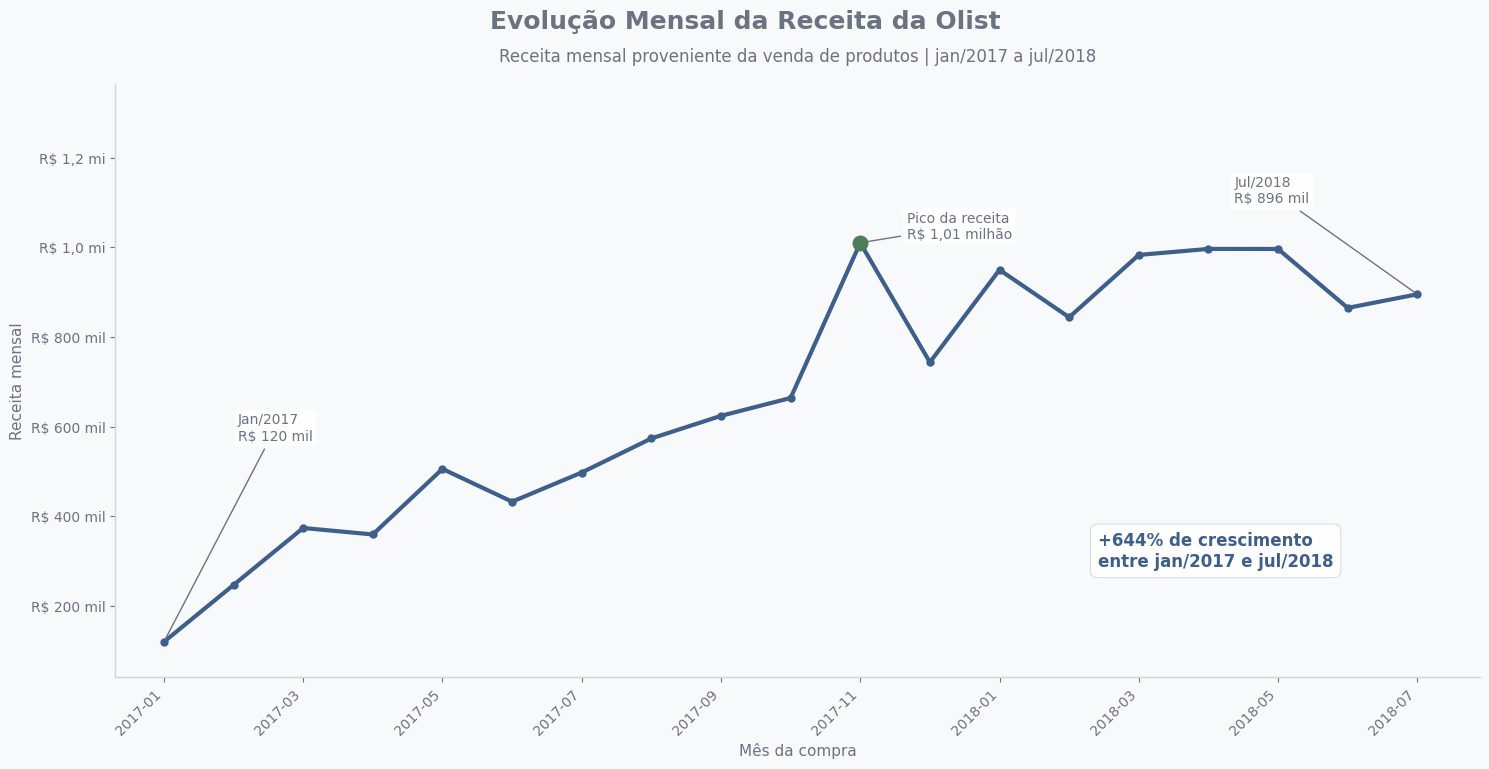

Imagem salva em:
/content/imagens/grafico_6_1_evolucao_mensal_receita_base_receita_item.png


ano_mes,receita_total,pedidos
2017-01,120312.870000,789
2017-02,247303.020000,1733
2017-03,374344.300000,2641
2017-04,359927.230000,2391
2017-05,506071.140000,3660
2017-06,433038.600000,3217
2017-07,498031.480000,3969
2017-08,573971.680000,4293
2017-09,624401.690000,4243
2017-10,664219.430000,4568


In [161]:
# ============================================================
# 6.1 - Evolução Mensal da Receita
# Base: base_receita_item
# Unidade de análise: item do pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base e colunas necessárias
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' não existe. Execute primeiro a célula 6.0."
    )

colunas_necessarias = ["order_id", "price", "ano_mes"]

for coluna in colunas_necessarias:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 2. Cálculo da receita mensal
# ============================================================

receita_mensal = (
    base_receita_item
    .dropna(subset=["ano_mes", "price", "order_id"])
    .groupby("ano_mes", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_mensal = receita_mensal.sort_values("ano_mes").reset_index(drop=True)
receita_mensal["x_pos"] = range(len(receita_mensal))

# ============================================================
# 3. Indicadores principais
# ============================================================

primeiro_mes = receita_mensal.iloc[0]
ultimo_mes = receita_mensal.iloc[-1]

maior_receita = receita_mensal.loc[
    receita_mensal["receita_total"].idxmax()
]

crescimento_receita = (
    (ultimo_mes["receita_total"] / primeiro_mes["receita_total"]) - 1
) * 100

# ============================================================
# 4. Funções de formatação monetária
# ============================================================

def moeda_eixo(x, pos):
    if x >= 1_000_000:
        return f"R$ {x / 1_000_000:.1f} mi".replace(".", ",")
    return f"R$ {x / 1000:.0f} mil"


def moeda_rotulo(valor):
    if valor >= 1_000_000:
        return f"R$ {valor / 1_000_000:.2f} milhão".replace(".", ",")
    return f"R$ {valor / 1000:.0f} mil"

# ============================================================
# 5. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7.8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    receita_mensal["x_pos"],
    receita_mensal["receita_total"],
    color=AZUL_EXECUTIVO,
    linewidth=3,
    marker="o",
    markersize=5
)

ax.scatter(
    maior_receita["x_pos"],
    maior_receita["receita_total"],
    color=VERDE_SOFISTICADO,
    s=120,
    zorder=5
)

# ============================================================
# 6. Títulos
# ============================================================

fig.suptitle(
    "Evolução Mensal da Receita da Olist",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.98
)

ax.set_title(
    "Receita mensal proveniente da venda de produtos | jan/2017 a jul/2018",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=16
)

# ============================================================
# 7. Caixa executiva
# ============================================================

ax.text(
    0.72,
    0.18,
    f"+{crescimento_receita:.0f}% de crescimento\nentre jan/2017 e jul/2018",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Rótulos estratégicos
# ============================================================

ax.annotate(
    f"Jan/2017\n{moeda_rotulo(primeiro_mes['receita_total'])}",
    xy=(primeiro_mes["x_pos"], primeiro_mes["receita_total"]),
    xytext=(0.09, 0.42),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

ax.annotate(
    f"Pico da receita\n{moeda_rotulo(maior_receita['receita_total'])}",
    xy=(maior_receita["x_pos"], maior_receita["receita_total"]),
    xytext=(0.58, 0.76),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

ax.annotate(
    f"Jul/2018\n{moeda_rotulo(ultimo_mes['receita_total'])}",
    xy=(ultimo_mes["x_pos"], ultimo_mes["receita_total"]),
    xytext=(0.82, 0.82),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

# ============================================================
# 9. Eixos e acabamento
# ============================================================

ax.set_ylabel("Receita mensal", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Mês da compra", fontsize=11, color=CINZA_EXECUTIVO)

ax.yaxis.set_major_formatter(FuncFormatter(moeda_eixo))

ax.set_xticks(receita_mensal["x_pos"][::2])
ax.set_xticklabels(
    receita_mensal["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_xlim(-0.7, len(receita_mensal) - 0.1)

ax.set_ylim(
    receita_mensal["receita_total"].min() * 0.35,
    receita_mensal["receita_total"].max() * 1.35
)

ax.grid(axis="y", alpha=0.20)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()



# ============================================================
# Salvamento da imagem
# ============================================================

from pathlib import Path

PASTA_IMAGENS = Path("imagens")
PASTA_IMAGENS.mkdir(exist_ok=True)

caminho_imagem = PASTA_IMAGENS / "grafico_6_1_evolucao_mensal_receita_base_receita_item.png"

plt.tight_layout()

plt.savefig(
    caminho_imagem,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Imagem salva em:")
print(caminho_imagem.resolve())


# ============================================================
# 11. Tabela executiva
# ============================================================

tabela_receita = receita_mensal[
    ["ano_mes", "receita_total", "pedidos"]
].copy()

tabela_receita["receita_total"] = tabela_receita["receita_total"].round(2)

display(
    tabela_executiva(tabela_receita)
)

### 6.2 - Evolução Mensal do Ticket Médio

Além do crescimento da receita, é importante compreender como o valor médio das compras se comportou ao longo do período analisado. O ticket médio representa o valor médio gasto pelos clientes em cada pedido e permite avaliar se a expansão do negócio ocorreu por compras de maior valor ou pelo aumento da quantidade de pedidos realizados.

A análise da evolução mensal do ticket médio complementa a avaliação financeira da plataforma, fornecendo uma visão mais detalhada dos fatores que contribuíram para o desempenho comercial observado. Ao comparar seu comportamento com a evolução da receita, torna-se possível identificar se o crescimento foi impulsionado por mudanças no padrão de consumo dos clientes ou pelo ganho de escala da operação.

Os resultados apresentados a seguir demonstram a evolução do ticket médio ao longo do período estudado, contribuindo para a compreensão da dinâmica de crescimento da Olist.


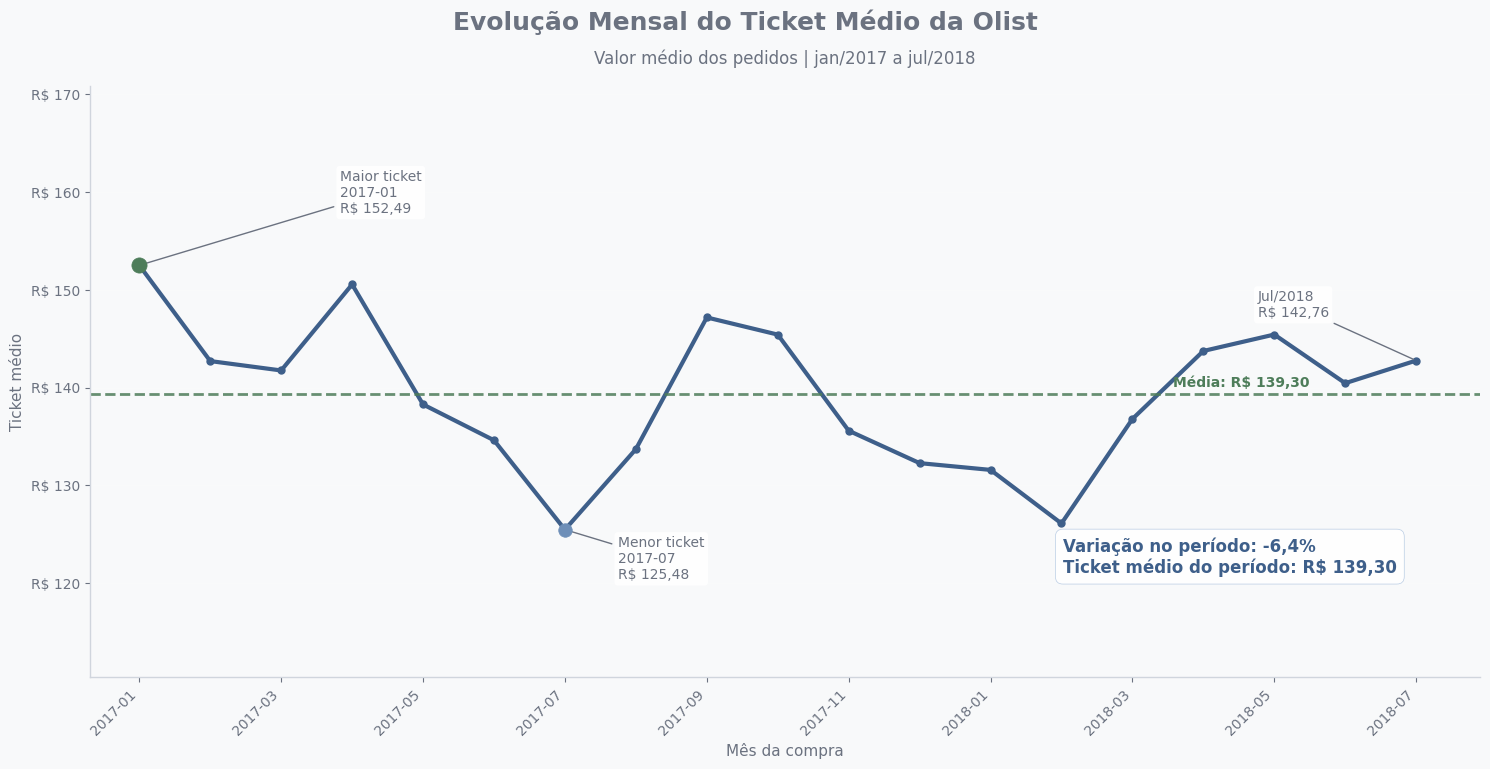

ano_mes,receita_total,pedidos,ticket_medio
2017-01,120312.870000,789,152.490000
2017-02,247303.020000,1733,142.700000
2017-03,374344.300000,2641,141.740000
2017-04,359927.230000,2391,150.530000
2017-05,506071.140000,3660,138.270000
2017-06,433038.600000,3217,134.610000
2017-07,498031.480000,3969,125.480000
2017-08,573971.680000,4293,133.700000
2017-09,624401.690000,4243,147.160000
2017-10,664219.430000,4568,145.410000


In [162]:
# ============================================================
# 6.2 - Evolução Mensal do Ticket Médio
# Base: base_receita_item
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base e colunas necessárias
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' não existe. Execute primeiro a célula 6.0."
    )

colunas_necessarias = ["order_id", "price", "ano_mes"]

for coluna in colunas_necessarias:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 2. Cálculo mensal da receita, pedidos e ticket médio
# ============================================================

ticket_mensal = (
    base_receita_item
    .dropna(subset=["ano_mes", "price", "order_id"])
    .groupby("ano_mes", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

ticket_mensal = ticket_mensal.sort_values("ano_mes").reset_index(drop=True)

ticket_mensal["ticket_medio"] = (
    ticket_mensal["receita_total"] / ticket_mensal["pedidos"]
)

ticket_mensal["x_pos"] = range(len(ticket_mensal))

# ============================================================
# 3. Indicadores principais
# ============================================================

primeiro_mes = ticket_mensal.iloc[0]
ultimo_mes = ticket_mensal.iloc[-1]

maior_ticket = ticket_mensal.loc[
    ticket_mensal["ticket_medio"].idxmax()
]

menor_ticket = ticket_mensal.loc[
    ticket_mensal["ticket_medio"].idxmin()
]

media_ticket = ticket_mensal["ticket_medio"].mean()

variacao_ticket = (
    (ultimo_mes["ticket_medio"] / primeiro_mes["ticket_medio"]) - 1
) * 100

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7.8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    ticket_mensal["x_pos"],
    ticket_mensal["ticket_medio"],
    color=AZUL_EXECUTIVO,
    linewidth=3,
    marker="o",
    markersize=5
)

# Linha de média do período
ax.axhline(
    media_ticket,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

# Destaque do maior ticket
ax.scatter(
    maior_ticket["x_pos"],
    maior_ticket["ticket_medio"],
    color=VERDE_SOFISTICADO,
    s=120,
    zorder=5
)

# Destaque do menor ticket
ax.scatter(
    menor_ticket["x_pos"],
    menor_ticket["ticket_medio"],
    color=AZUL_MEDIO,
    s=95,
    zorder=5
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Evolução Mensal do Ticket Médio da Olist",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.98
)

ax.set_title(
    "Valor médio dos pedidos | jan/2017 a jul/2018",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=16
)

# ============================================================
# 6. Caixa executiva
# ============================================================

ax.text(
    0.70,
    0.17,
    (
        f"Variação no período: {variacao_ticket:+.1f}%\n"
        f"Ticket médio do período: R$ {media_ticket:.2f}"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 7. Rótulos estratégicos
# ============================================================

ax.annotate(
    f"Maior ticket\n{maior_ticket['ano_mes']}\nR$ {maior_ticket['ticket_medio']:.2f}".replace(".", ","),
    xy=(maior_ticket["x_pos"], maior_ticket["ticket_medio"]),
    xytext=(0.18, 0.82),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.annotate(
    f"Menor ticket\n{menor_ticket['ano_mes']}\nR$ {menor_ticket['ticket_medio']:.2f}".replace(".", ","),
    xy=(menor_ticket["x_pos"], menor_ticket["ticket_medio"]),
    xytext=(0.38, 0.20),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.annotate(
    f"Jul/2018\nR$ {ultimo_mes['ticket_medio']:.2f}".replace(".", ","),
    xy=(ultimo_mes["x_pos"], ultimo_mes["ticket_medio"]),
    xytext=(0.84, 0.63),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.text(
    ticket_mensal["x_pos"].max() - 1.5,
    media_ticket + 0.8,
    f"Média: R$ {media_ticket:.2f}".replace(".", ","),
    fontsize=10,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="right"
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_ylabel("Ticket médio", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Mês da compra", fontsize=11, color=CINZA_EXECUTIVO)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"R$ {x:.0f}".replace(".", ","))
)

ax.set_xticks(ticket_mensal["x_pos"][::2])
ax.set_xticklabels(
    ticket_mensal["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_xlim(-0.7, len(ticket_mensal) - 0.1)

ax.set_ylim(
    ticket_mensal["ticket_medio"].min() * 0.88,
    ticket_mensal["ticket_medio"].max() * 1.12
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_6_2_evolucao_ticket_medio_base_receita_item.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()


# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_ticket = ticket_mensal[
    ["ano_mes", "receita_total", "pedidos", "ticket_medio"]
].copy()

tabela_ticket["receita_total"] = tabela_ticket["receita_total"].round(2)
tabela_ticket["ticket_medio"] = tabela_ticket["ticket_medio"].round(2)

display(
    tabela_executiva(tabela_ticket)
)

### 6.3 - Participação da Receita por Categoria

A distribuição da receita entre as categorias de produtos permite compreender quais segmentos possuem maior contribuição para o desempenho financeiro da plataforma. Em marketplaces com portfólio diversificado, é comum que parte relevante da receita esteja concentrada em um grupo específico de categorias, tornando importante identificar quais delas exercem maior influência sobre os resultados do negócio.

A análise da participação da receita por categoria contribui para a compreensão da composição comercial da Olist, evidenciando os segmentos que apresentam maior representatividade no faturamento total. Essa visão permite avaliar o grau de concentração da receita e identificar categorias com potencial estratégico para a sustentação do crescimento da plataforma.

Os resultados apresentados a seguir demonstram a participação das principais categorias na receita total da Olist, permitindo identificar os segmentos mais relevantes para o desempenho comercial do marketplace.


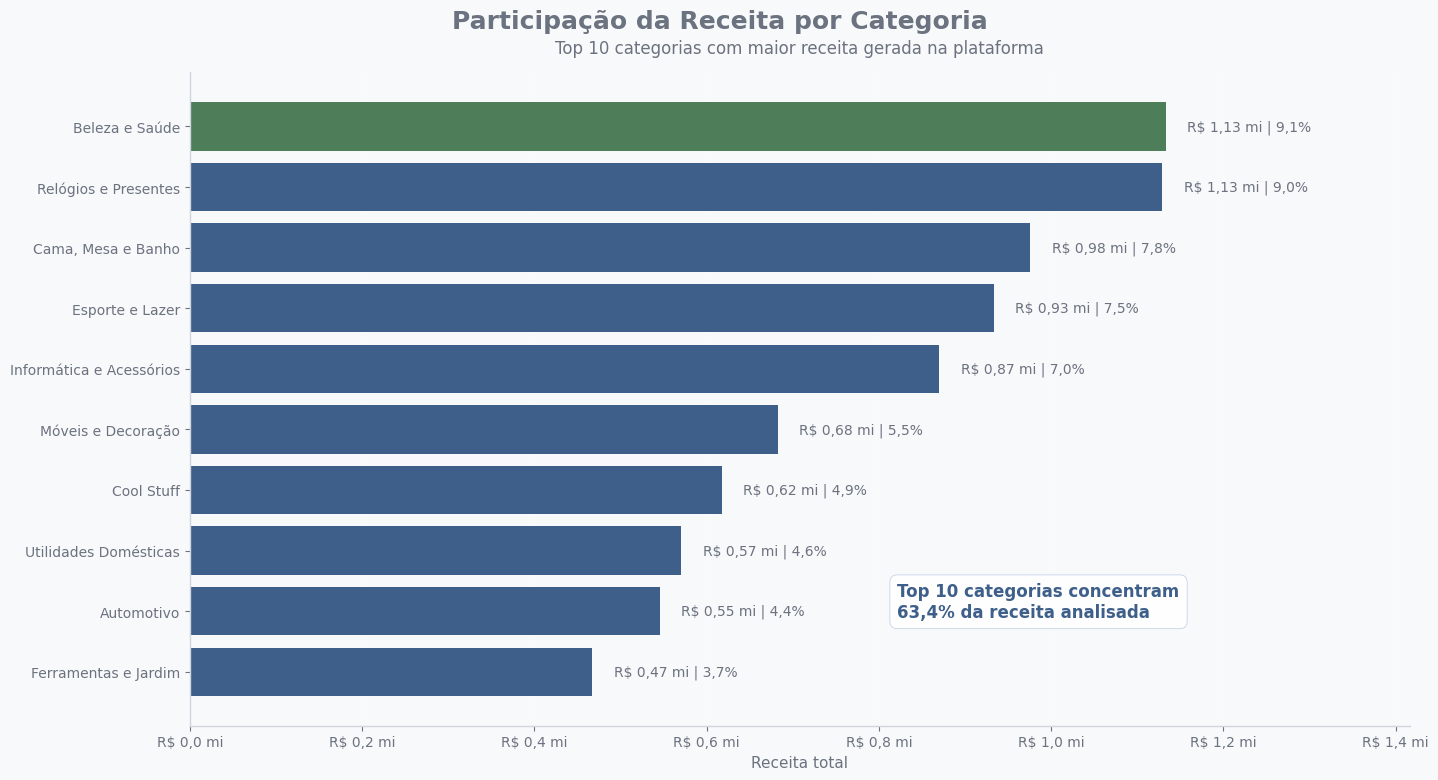

categoria_executiva,receita_total,participacao_receita,pedidos
Beleza e Saúde,1133189.920000,9.100000,8013
Relógios e Presentes,1129368.380000,9.000000,5227
"Cama, Mesa e Banho",975473.810000,7.800000,8854
Esporte e Lazer,933215.170000,7.500000,7265
Informática e Acessórios,870261.070000,7.000000,6287
Móveis e Decoração,682501.560000,5.500000,6053
Cool Stuff,617825.270000,4.900000,3504
Utilidades Domésticas,570758.920000,4.600000,5313
Automotivo,545505.970000,4.400000,3534
Ferramentas e Jardim,467464.240000,3.700000,3391


In [163]:
# ============================================================
# 6.3 - Participação da Receita por Categoria
# Versão executiva
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Função para formatar categorias
# ============================================================

def formatar_categoria(nome):
    nome_formatado = (
        str(nome)
        .replace("_", " ")
        .replace("-", " ")
        .strip()
        .title()
    )

    ajustes = {
        "Beleza Saude": "Beleza e Saúde",
        "Relogios Presentes": "Relógios e Presentes",
        "Cama Mesa Banho": "Cama, Mesa e Banho",
        "Esporte Lazer": "Esporte e Lazer",
        "Informatica Acessorios": "Informática e Acessórios",
        "Moveis Decoracao": "Móveis e Decoração",
        "Utilidades Domesticas": "Utilidades Domésticas",
        "Ferramentas Jardim": "Ferramentas e Jardim",
        "Moveis Escritorio": "Móveis de Escritório",
        "Construcao Ferramentas Construcao": "Construção e Ferramentas",
        "Casa Construcao": "Casa e Construção",
        "Telefonia": "Telefonia",
        "Automotivo": "Automotivo",
        "Brinquedos": "Brinquedos"
    }

    return ajustes.get(nome_formatado, nome_formatado)

# ============================================================
# Função de formatação monetária
# ============================================================

def moeda_milhoes(x, pos):
    return f"R$ {x / 1_000_000:.1f} mi".replace(".", ",")

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = ["order_id", "price"]

for coluna in colunas_necessarias:
    if coluna not in base_satisfacao.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_satisfacao.")

if "categoria_produto" in base_satisfacao.columns:
    coluna_categoria = "categoria_produto"
elif "product_category_name" in base_satisfacao.columns:
    coluna_categoria = "product_category_name"
elif "product_category_name_english" in base_satisfacao.columns:
    coluna_categoria = "product_category_name_english"
else:
    raise KeyError(
        "Não foi encontrada coluna de categoria em base_satisfacao."
    )

# ============================================================
# 2. Preparação da base
# ============================================================

df_categoria = base_receita_item.copy()

df_categoria = df_categoria.dropna(
    subset=[coluna_categoria, "price", "order_id"]
).copy()

df_categoria["categoria_executiva"] = (
    df_categoria[coluna_categoria]
    .apply(formatar_categoria)
)

# ============================================================
# 3. Cálculo da receita por categoria
# ============================================================

receita_total = df_categoria["price"].sum()

receita_categoria = (
    df_categoria
    .groupby("categoria_executiva", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_categoria["participacao_receita"] = (
    receita_categoria["receita_total"] / receita_total
) * 100

top10_categoria = (
    receita_categoria
    .sort_values("receita_total", ascending=False)
    .head(10)
    .copy()
)

top10_categoria = top10_categoria.sort_values(
    "receita_total",
    ascending=True
)

participacao_top10 = top10_categoria["participacao_receita"].sum()
categoria_lider = top10_categoria.iloc[-1]

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14.5, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if categoria == categoria_lider["categoria_executiva"]
    else AZUL_EXECUTIVO
    for categoria in top10_categoria["categoria_executiva"]
]

barras = ax.barh(
    top10_categoria["categoria_executiva"],
    top10_categoria["receita_total"],
    color=cores
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Participação da Receita por Categoria",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Top 10 categorias com maior receita gerada na plataforma",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 6. Rótulos das barras
# ============================================================

for barra, valor, participacao in zip(
    barras,
    top10_categoria["receita_total"],
    top10_categoria["participacao_receita"]
):
    ax.text(
        barra.get_width() + receita_total * 0.002,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {valor / 1_000_000:.2f} mi | {participacao:.1f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 7. Caixa executiva
# ============================================================

ax.text(
    0.58,
    0.16,
    (
        f"Top 10 categorias concentram\n"
        f"{participacao_top10:.1f}% da receita analisada"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Receita total", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(FuncFormatter(moeda_milhoes))

ax.set_xlim(
    0,
    top10_categoria["receita_total"].max() * 1.25
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_6_3_receita_por_categoria.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()


# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_categoria = top10_categoria.sort_values(
    "receita_total",
    ascending=False
).copy()

tabela_categoria["receita_total"] = tabela_categoria["receita_total"].round(2)
tabela_categoria["participacao_receita"] = tabela_categoria["participacao_receita"].round(1)

display(
    tabela_executiva(
        tabela_categoria[
            [
                "categoria_executiva",
                "receita_total",
                "participacao_receita",
                "pedidos"
            ]
        ]
    )
)

# 7 - Perfil da Satisfação dos Clientes

## Objetivo da Seção

Após compreender o comportamento operacional e comercial da Olist, esta seção apresenta uma visão geral da satisfação dos clientes a partir das avaliações registradas na plataforma.

As análises desenvolvidas possuem caráter predominantemente descritivo e buscam responder à pergunta:

**Como os clientes avaliam a experiência de compra na Olist?**

Serão exploradas a distribuição das avaliações e as diferenças observadas entre categorias e regiões, permitindo compreender o perfil geral da satisfação antes da investigação dos fatores que a influenciam.

Os resultados desta seção servirão de base para a análise dos drivers de satisfação apresentada na seção seguinte.

In [164]:
# ============================================================
# Preparação da base para o gráfico:
# Evolução da Satisfação Média e Volume de Avaliações
# ============================================================

import pandas as pd

# Use a base que já contém pedido + avaliação
# No seu projeto, normalmente é base_driver ou base_satisfacao
df = base_driver.copy()

# Validação das colunas necessárias
colunas_necessarias = ["order_id", "review_score", "order_purchase_timestamp"]

for coluna in colunas_necessarias:
    if coluna not in df.columns:
        raise KeyError(f"A coluna '{coluna}' não existe na base utilizada.")

# Garante que a data está em formato datetime
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

# Remove registros sem data ou sem avaliação
df = df.dropna(subset=["order_purchase_timestamp", "review_score"])

# Remove duplicidade de pedidos, se existir
df = df.drop_duplicates(subset=["order_id"])

# Cria ano/mês
df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Calcula satisfação média e volume de avaliações por mês
satisfacao_mensal = (
    df.groupby("ano_mes")
    .agg(
        satisfacao_media=("review_score", "mean"),
        total_avaliacoes=("review_score", "count")
    )
    .reset_index()
)

# Ordena corretamente por mês
satisfacao_mensal["ano_mes_ordem"] = pd.to_datetime(satisfacao_mensal["ano_mes"])
satisfacao_mensal = (
    satisfacao_mensal
    .sort_values("ano_mes_ordem")
    .drop(columns="ano_mes_ordem")
    .reset_index(drop=True)
)

satisfacao_mensal.head()

,ano_mes,satisfacao_media,total_avaliacoes
0,2016-09,1.00,3
1,2016-10,3.69,303
2,2016-12,5.00,1
3,2017-01,4.09,779
4,2017-02,4.08,1722


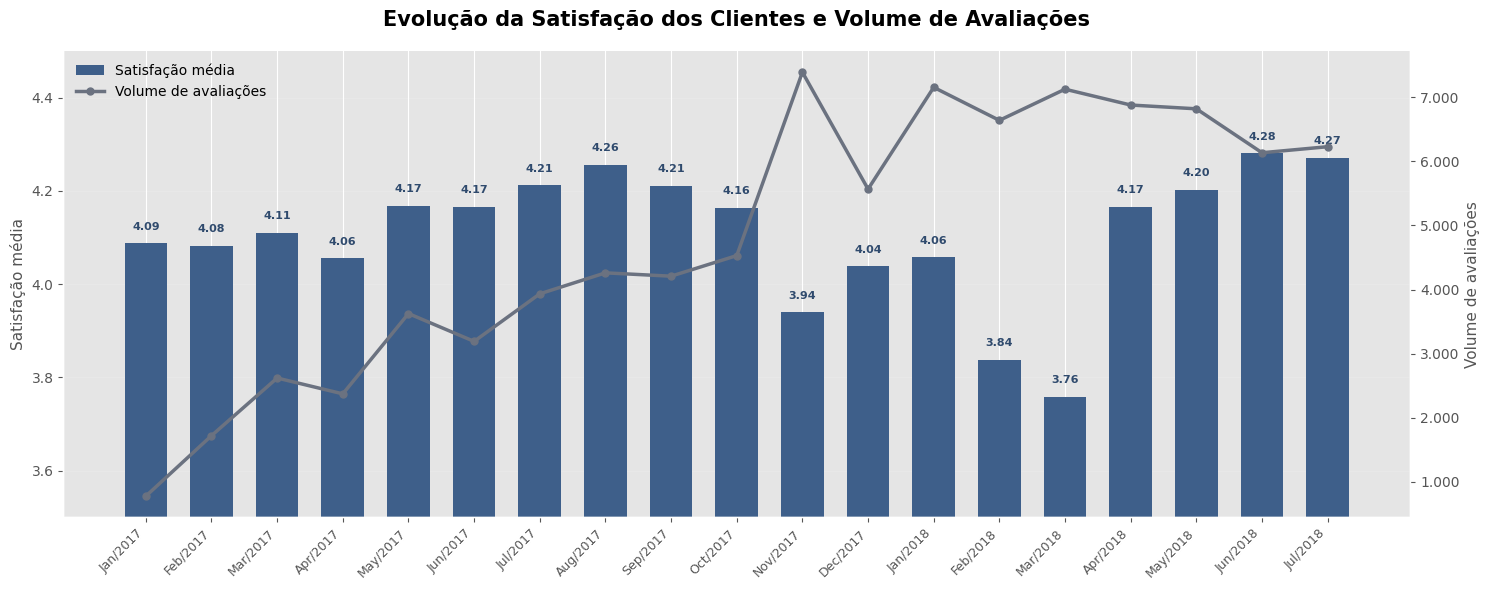

In [165]:
# ============================================================
# Evolução da Satisfação dos Clientes e Volume de Avaliações
# Período analisado: jan/2017 a jul/2018
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = [
    "order_id",
    "review_score",
    "order_purchase_timestamp"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

# ============================================================
# 2. Preparação da base
# ============================================================

df_satisfacao = base_driver[
    [
        "order_id",
        "review_score",
        "order_purchase_timestamp"
    ]
].copy()

df_satisfacao["order_purchase_timestamp"] = pd.to_datetime(
    df_satisfacao["order_purchase_timestamp"],
    errors="coerce"
)

df_satisfacao = df_satisfacao.dropna(
    subset=[
        "order_id",
        "review_score",
        "order_purchase_timestamp"
    ]
)

# Evita duplicidade de pedido
df_satisfacao = df_satisfacao.drop_duplicates(subset=["order_id"])

# Recorte temporal consistente
df_satisfacao = df_satisfacao[
    (df_satisfacao["order_purchase_timestamp"] >= "2017-01-01") &
    (df_satisfacao["order_purchase_timestamp"] < "2018-08-01")
].copy()

# Cria ano/mês
df_satisfacao["ano_mes"] = (
    df_satisfacao["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# ============================================================
# 3. Consolidação mensal
# ============================================================

satisfacao_mensal = (
    df_satisfacao
    .groupby("ano_mes")
    .agg(
        satisfacao_media=("review_score", "mean"),
        total_avaliacoes=("review_score", "count")
    )
    .reset_index()
)

satisfacao_mensal["ano_mes_data"] = pd.to_datetime(
    satisfacao_mensal["ano_mes"]
)

satisfacao_mensal = satisfacao_mensal.sort_values("ano_mes_data")

satisfacao_mensal["ano_mes_formatado"] = (
    satisfacao_mensal["ano_mes_data"]
    .dt.strftime("%b/%Y")
)

# ============================================================
# 4. Gráfico
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 6))

x = range(len(satisfacao_mensal))

# Barras - satisfação média
barras = ax1.bar(
    x,
    satisfacao_mensal["satisfacao_media"],
    color="#3E5F8A",
    width=0.65,
    label="Satisfação média"
)

# Rótulos das barras
for barra in barras:
    altura = barra.get_height()
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.025,
        f"{altura:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#2F4A6D",
        fontweight="bold"
    )

ax1.set_ylabel("Satisfação média", fontsize=11)
ax1.set_ylim(3.5, 4.5)

# Linha - volume de avaliações
ax2 = ax1.twinx()

ax2.plot(
    x,
    satisfacao_mensal["total_avaliacoes"],
    color="#6B7280",
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="Volume de avaliações"
)

ax2.set_ylabel("Volume de avaliações", fontsize=11)

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"{int(valor):,}".replace(",", "."))
)

# Eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(
    satisfacao_mensal["ano_mes_formatado"],
    rotation=45,
    ha="right",
    fontsize=9
)

# Título
ax1.set_title(
    "Evolução da Satisfação dos Clientes e Volume de Avaliações",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# Legenda
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=False,
    fontsize=10
)

# Limpeza visual
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.grid(axis="y", alpha=0.15)
ax2.grid(False)

plt.tight_layout()

# Exporta em alta qualidade
plt.savefig(
    "grafico_evolucao_satisfacao_volume_avaliacoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [166]:
[col for col in base_driver.columns if "state" in col.lower()]

['customer_state']

In [167]:
[col for col in base_driver.columns if "customer" in col.lower()]

['customer_id',
 'order_delivered_customer_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [168]:
base_driver.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'tempo_entrega',
 'dias_atraso',
 'dias_atraso_real',
 'dias_antecipacao',
 'ano_mes']

In [169]:
# ============================================================
# Criação da coluna região
# ============================================================

mapa_regioes = {
    "AC":"Norte","AP":"Norte","AM":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",

    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste",
    "PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",

    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",

    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",

    "PR":"Sul","RS":"Sul","SC":"Sul"
}

base_driver["regiao"] = (
    base_driver["customer_state"]
    .map(mapa_regioes)
)

In [170]:
# ============================================================
# Prazo médio de entrega por mês
# ============================================================

base_driver["ano_mes"] = (
    pd.to_datetime(
        base_driver["order_purchase_timestamp"]
    )
    .dt.to_period("M")
    .astype(str)
)

prazo_mensal = (
    base_driver
    .drop_duplicates(subset=["order_id"])
    .groupby("ano_mes")
    ["tempo_entrega"]
    .mean()
    .reset_index()
)

prazo_mensal

,ano_mes,tempo_entrega
0,2016-09,54.00
1,2016-10,19.11
2,2016-12,4.00
3,2017-01,12.09
4,2017-02,12.61
5,2017-03,12.40
6,2017-04,14.35
7,2017-05,10.76
8,2017-06,11.51
9,2017-07,11.13


In [171]:
mes_problema = "2018-03"

(
    base_driver[
        base_driver["ano_mes"] == mes_problema
    ]
    .groupby("product_category_name")
    ["review_score"]
    .mean()
    .sort_values()
    .head(10)
)

,review_score
product_category_name,
fraldas_higiene,2.00
cine_foto,2.50
audio,2.94
artigos_de_natal,3.00
fashion_underwear_e_moda_praia,3.00
fashion_calcados,3.25
casa_conforto,3.25
telefonia_fixa,3.33
construcao_ferramentas_iluminacao,3.42


In [172]:
# ============================================================
# % de pedidos atrasados por mês
# Base: base_driver
# Unidade: pedido
# ============================================================

import pandas as pd

df_atrasos = base_driver.copy()

# Validação das colunas necessárias
colunas_necessarias = [
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for coluna in colunas_necessarias:
    if coluna not in df_atrasos.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

# Conversão das datas
df_atrasos["order_purchase_timestamp"] = pd.to_datetime(
    df_atrasos["order_purchase_timestamp"],
    errors="coerce"
)

df_atrasos["order_delivered_customer_date"] = pd.to_datetime(
    df_atrasos["order_delivered_customer_date"],
    errors="coerce"
)

df_atrasos["order_estimated_delivery_date"] = pd.to_datetime(
    df_atrasos["order_estimated_delivery_date"],
    errors="coerce"
)

# Remove duplicidade por pedido
df_atrasos = df_atrasos.drop_duplicates(subset=["order_id"])

# Remove registros sem datas necessárias
df_atrasos = df_atrasos.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Recorte temporal consistente
df_atrasos = df_atrasos[
    (df_atrasos["order_purchase_timestamp"] >= "2017-01-01") &
    (df_atrasos["order_purchase_timestamp"] < "2018-08-01")
].copy()

# Cria ano/mês
df_atrasos["ano_mes"] = (
    df_atrasos["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Cria coluna de atraso:
# atraso > 0 significa que entregou depois da data estimada
df_atrasos["dias_atraso"] = (
    df_atrasos["order_delivered_customer_date"] -
    df_atrasos["order_estimated_delivery_date"]
).dt.days

df_atrasos["pedido_atrasado"] = df_atrasos["dias_atraso"] > 0

# Consolidação mensal
atrasos_mes = (
    df_atrasos
    .groupby("ano_mes")
    .agg(
        pedidos=("order_id", "count"),
        pedidos_atrasados=("pedido_atrasado", "sum"),
        taxa_atraso=("pedido_atrasado", "mean"),
        atraso_medio=("dias_atraso", "mean")
    )
    .reset_index()
)

atrasos_mes["taxa_atraso"] = atrasos_mes["taxa_atraso"] * 100

atrasos_mes

,ano_mes,pedidos,pedidos_atrasados,taxa_atraso,atraso_medio
0,2017-01,750,22,2.93,-27.41
1,2017-02,1653,49,2.96,-19.20
2,2017-03,2546,116,4.56,-12.33
3,2017-04,2303,151,6.56,-12.97
4,2017-05,3545,106,2.99,-13.50
5,2017-06,3135,95,3.03,-12.64
6,2017-07,3872,108,2.79,-12.47
7,2017-08,4193,122,2.91,-13.10
8,2017-09,4150,182,4.39,-11.35
9,2017-10,4478,187,4.18,-11.92


In [173]:
(
    base_driver[
        base_driver["ano_mes"] == "2018-03"
    ]
    .groupby("regiao")
    ["review_score"]
    .mean()
    .sort_values()
)

,review_score
regiao,
Norte,2.94
Nordeste,3.42
Centro-Oeste,3.65
Sul,3.81
Sudeste,3.82


### 7.1 - Distribuição das Avaliações dos Clientes

A satisfação dos clientes representa um dos principais indicadores da qualidade da experiência oferecida por uma plataforma de e-commerce. A análise das avaliações permite compreender como os consumidores percebem suas compras e identificar padrões de satisfação e insatisfação ao longo da base de pedidos.

A distribuição das notas atribuídas pelos clientes fornece uma visão geral da experiência de compra na Olist, evidenciando a frequência com que avaliações positivas, neutras e negativas ocorrem. Essa análise contribui para avaliar a percepção dos consumidores sobre a plataforma e identificar possíveis oportunidades de melhoria na jornada de compra.

Os resultados apresentados a seguir demonstram a distribuição das avaliações registradas pelos clientes, permitindo compreender o nível geral de satisfação observado na operação da Olist.


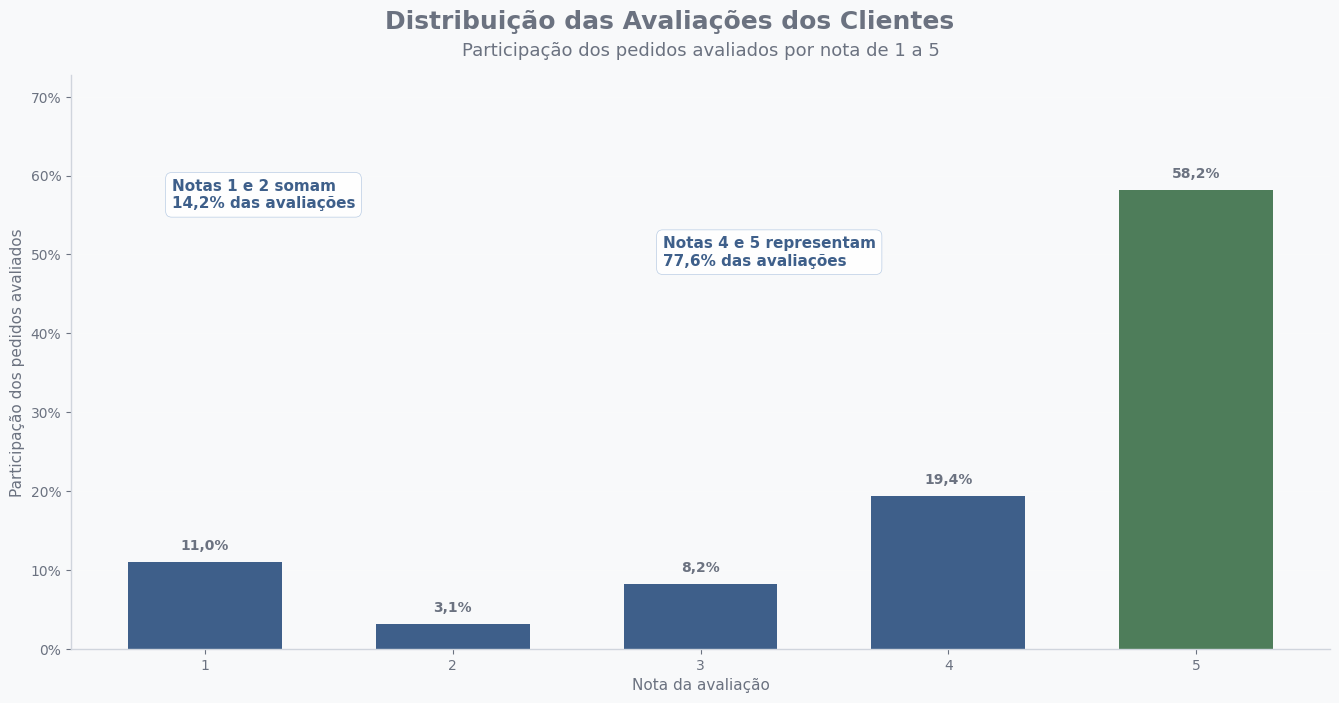

nota,percentual
1,11.000000
2,3.100000
3,8.200000
4,19.400000
5,58.200000


In [174]:
# ============================================================
# 7.1 - Distribuição das Avaliações dos Clientes
# Versão executiva revisada
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = ["order_id", "review_score"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_driver.")

# ============================================================
# 2. Preparação da base
# ============================================================

df_review = (
    base_driver[["order_id", "review_score"]]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_review["review_score"] = df_review["review_score"].astype(int)

# ============================================================
# 3. Distribuição das avaliações
# ============================================================

dist_review = (
    df_review["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

dist_review.columns = ["nota", "percentual"]

avaliacoes_positivas = dist_review.loc[
    dist_review["nota"].isin([4, 5]), "percentual"
].sum()

avaliacoes_negativas = dist_review.loc[
    dist_review["nota"].isin([1, 2]), "percentual"
].sum()

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(13.5, 7.2), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if nota == 5 else AZUL_EXECUTIVO
    for nota in dist_review["nota"]
]

barras = ax.bar(
    dist_review["nota"].astype(str),
    dist_review["percentual"],
    color=cores,
    width=0.62
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Distribuição das Avaliações dos Clientes",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Participação dos pedidos avaliados por nota de 1 a 5",
    fontsize=13,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 6. Rótulos das barras
# ============================================================

for barra, valor in zip(barras, dist_review["percentual"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1.2,
        f"{valor:.1f}%".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 7. Caixas executivas
# ============================================================

ax.text(
    0.08,
    0.82,
    f"Notas 1 e 2 somam\n{avaliacoes_negativas:.1f}% das avaliações".replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.40",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.text(
    0.47,
    0.72,
    f"Notas 4 e 5 representam\n{avaliacoes_positivas:.1f}% das avaliações".replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.40",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Nota da avaliação", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("Participação dos pedidos avaliados", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_ylim(0, max(dist_review["percentual"]) * 1.25)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_7_1_distribuicao_avaliacoes.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()


# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_7_1 = dist_review.copy()
tabela_7_1["percentual"] = tabela_7_1["percentual"].round(1)

display(
    tabela_executiva(tabela_7_1)
)

### 7.2 - Avaliação Média por Categoria

A experiência do cliente pode variar significativamente entre diferentes categorias de produtos, uma vez que cada segmento possui características próprias relacionadas ao processo de compra, transporte, entrega e expectativas dos consumidores. Compreender essas diferenças é fundamental para identificar possíveis oportunidades de melhoria e segmentos que merecem atenção específica.

A análise da avaliação média por categoria permite comparar a percepção dos clientes entre os diversos grupos de produtos comercializados na plataforma. Essa visão contribui para identificar categorias que apresentam melhor desempenho em termos de satisfação, bem como segmentos que podem estar associados a maiores desafios operacionais ou de experiência do cliente.

Os resultados apresentados a seguir demonstram a avaliação média das categorias de produtos da Olist, permitindo identificar os segmentos mais e menos bem avaliados pelos consumidores.


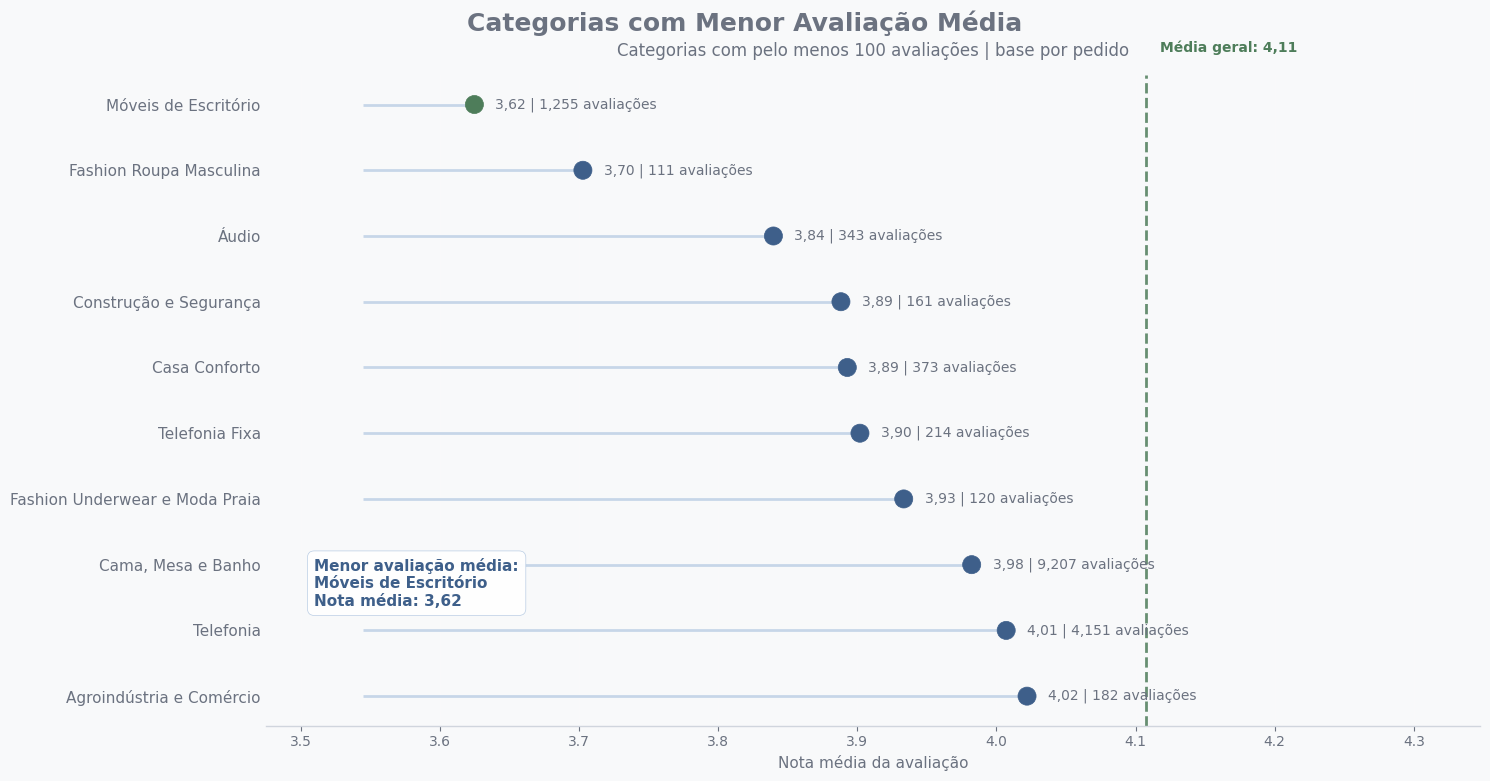

categoria,nota_media,qtd_avaliacoes
Móveis de Escritório,3.620000,1255
Fashion Roupa Masculina,3.700000,111
Áudio,3.840000,343
Construção e Segurança,3.890000,161
Casa Conforto,3.890000,373
Telefonia Fixa,3.900000,214
Fashion Underwear e Moda Praia,3.930000,120
"Cama, Mesa e Banho",3.980000,9207
Telefonia,4.010000,4151
Agroindústria e Comércio,4.020000,182


In [175]:
# ============================================================
# 7.3 - Avaliação Média por Categoria
# Versão final revisada em Dot Plot
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

def formatar_categoria(nome):
    nome = str(nome).replace("_", " ").replace("-", " ").strip().title()

    ajustes = {
        "Moveis Escritorio": "Móveis de Escritório",
        "Fashion Roupa Masculina": "Fashion Roupa Masculina",
        "Audio": "Áudio",
        "Construcao Ferramentas Seguranca": "Construção e Segurança",
        "Casa Conforto": "Casa Conforto",
        "Telefonia Fixa": "Telefonia Fixa",
        "Fashion Underwear E Moda Praia": "Fashion Underwear e Moda Praia",
        "Cama Mesa Banho": "Cama, Mesa e Banho",
        "Telefonia": "Telefonia",
        "Agro Industria E Comercio": "Agroindústria e Comércio"
    }

    return ajustes.get(nome, nome)

colunas_necessarias = ["product_category_name", "review_score", "order_id"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

df_categoria = (
    base_driver[["product_category_name", "review_score", "order_id"]]
    .dropna()
    .copy()
)

df_categoria["review_score"] = df_categoria["review_score"].astype(float)

MIN_AVALIACOES = 100

avaliacao_categoria = (
    df_categoria
    .groupby("product_category_name", as_index=False)
    .agg(
        nota_media=("review_score", "mean"),
        qtd_avaliacoes=("order_id", "nunique")
    )
)

avaliacao_categoria = (
    avaliacao_categoria[
        avaliacao_categoria["qtd_avaliacoes"] >= MIN_AVALIACOES
    ]
    .copy()
)

avaliacao_categoria["categoria_formatada"] = (
    avaliacao_categoria["product_category_name"].apply(formatar_categoria)
)

top10 = (
    avaliacao_categoria
    .sort_values("nota_media", ascending=True)
    .head(10)
    .copy()
)

top10_plot = (
    top10
    .sort_values("nota_media", ascending=False)
    .reset_index(drop=True)
)

media_geral = df_categoria["review_score"].mean()
categoria_pior = top10.loc[top10["nota_media"].idxmin()]

fig, ax = plt.subplots(figsize=(15, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

x_inicio = top10_plot["nota_media"].min() - 0.08

for i, row in top10_plot.iterrows():
    ax.hlines(
        y=i,
        xmin=x_inicio,
        xmax=row["nota_media"],
        color=AZUL_CLARO,
        linewidth=2,
        alpha=0.75
    )

cores = [
    VERDE_SOFISTICADO if categoria == categoria_pior["categoria_formatada"]
    else AZUL_EXECUTIVO
    for categoria in top10_plot["categoria_formatada"]
]

ax.scatter(
    top10_plot["nota_media"],
    range(len(top10_plot)),
    s=170,
    color=cores,
    zorder=3
)

ax.axvline(
    media_geral,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

for i, row in top10_plot.iterrows():
    ax.text(
        row["nota_media"] + 0.015,
        i,
        f"{row['nota_media']:.2f} | {row['qtd_avaliacoes']:,} avaliações".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

ax.text(
    media_geral + 0.01,
    len(top10_plot) - 0.25,
    f"Média geral: {media_geral:.2f}".replace(".", ","),
    fontsize=10,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="left",
    va="bottom"
)

fig.suptitle(
    "Categorias com Menor Avaliação Média",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    f"Categorias com pelo menos {MIN_AVALIACOES} avaliações | base por pedido",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

ax.text(
    0.04,
    0.18,
    (
        f"Menor avaliação média:\n"
        f"{categoria_pior['categoria_formatada']}\n"
        f"Nota média: {categoria_pior['nota_media']:.2f}"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_yticks(range(len(top10_plot)))
ax.set_yticklabels(
    top10_plot["categoria_formatada"],
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_xlabel("Nota média da avaliação", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("")

ax.set_xlim(
    top10_plot["nota_media"].min() - 0.15,
    max(media_geral, top10_plot["nota_media"].max()) + 0.24
)

ax.grid(axis="x", alpha=0.16)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="x", colors=CINZA_EXECUTIVO)
ax.tick_params(axis="y", colors=CINZA_EXECUTIVO, length=0)

plt.tight_layout()

nome_arquivo = "grafico_7_3_avaliacao_media_categoria_final.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()


tabela_categoria = top10.copy()
tabela_categoria["nota_media"] = tabela_categoria["nota_media"].round(2)

tabela_categoria = tabela_categoria.rename(columns={
    "categoria_formatada": "categoria",
    "qtd_avaliacoes": "qtd_avaliacoes"
})

display(
    tabela_executiva(
        tabela_categoria[
            ["categoria", "nota_media", "qtd_avaliacoes"]
        ]
    )
)


### 7.3 - Promotores, Neutros e Detratores por Região

Além da análise da avaliação média, é importante compreender como os diferentes perfis de satisfação estão distribuídos entre as regiões do país. A segmentação dos clientes em promotores, neutros e detratores permite uma visão mais detalhada da experiência percebida, evidenciando diferenças que podem não ser totalmente capturadas pela nota média isoladamente.

A análise da distribuição desses grupos por região contribui para identificar padrões geográficos de satisfação, destacando mercados com maior concentração de clientes engajados e regiões que apresentam maior risco de insatisfação. Essa abordagem amplia a compreensão das diferenças regionais observadas na operação e auxilia na identificação de oportunidades de melhoria da experiência do cliente.

Os resultados apresentados a seguir demonstram a composição de promotores, neutros e detratores nas diferentes regiões brasileiras, permitindo avaliar como a satisfação dos clientes se distribui geograficamente na plataforma.


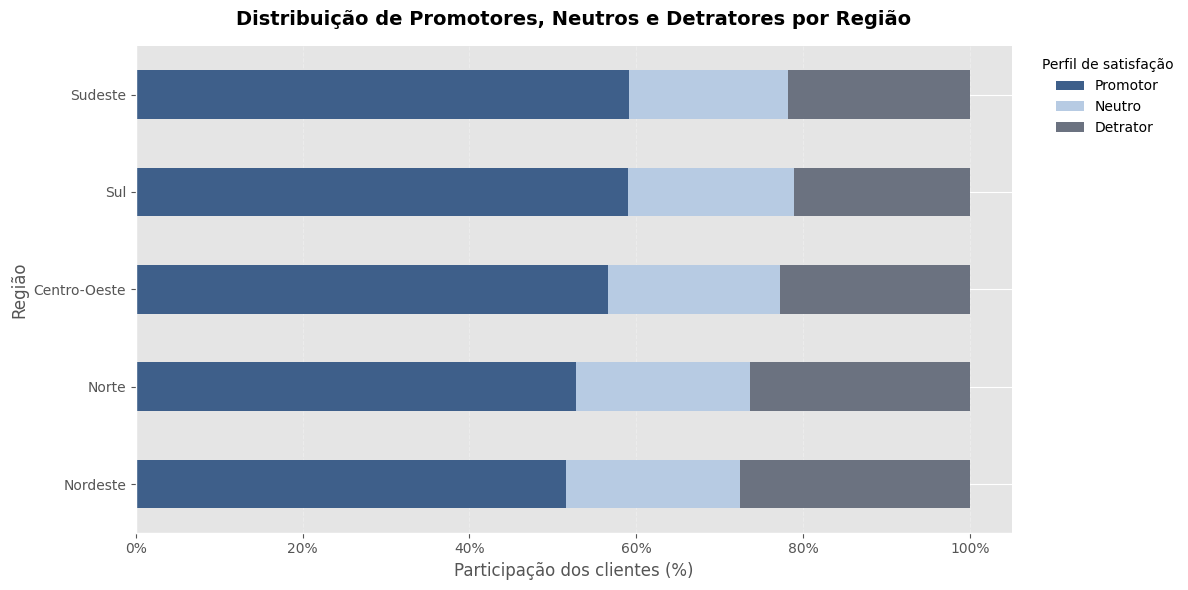

In [176]:
# ============================================================
# 7.6 - Promotores, Neutros e Detratores por Região
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# Validação das colunas necessárias
# ============================================================

colunas_necessarias = [
    "order_id",
    "customer_state",
    "review_score"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Mapeamento dos estados brasileiros para regiões
# ============================================================

mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte",
    "RO": "Norte", "RR": "Norte", "TO": "Norte",

    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste",
    "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste",
    "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",

    "DF": "Centro-Oeste", "GO": "Centro-Oeste",
    "MT": "Centro-Oeste", "MS": "Centro-Oeste",

    "ES": "Sudeste", "MG": "Sudeste",
    "RJ": "Sudeste", "SP": "Sudeste",

    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

# ============================================================
# Preparação da base
# Mantém uma linha por pedido para evitar duplicidade por itens
# ============================================================

df_nps_regiao = (
    base_driver[
        ["order_id", "customer_state", "review_score"]
    ]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_nps_regiao["regiao"] = (
    df_nps_regiao["customer_state"]
    .map(mapa_regioes)
)

# ============================================================
# Classificação dos clientes
# Padrão do projeto:
# Detrator: notas 1, 2 e 3
# Neutro: nota 4
# Promotor: nota 5
# ============================================================

def classificar_satisfacao(nota):
    if nota in [1, 2, 3]:
        return "Detrator"
    elif nota == 4:
        return "Neutro"
    else:
        return "Promotor"

df_nps_regiao["grupo_satisfacao"] = (
    df_nps_regiao["review_score"]
    .astype(int)
    .apply(classificar_satisfacao)
)

# ============================================================
# Tabela percentual por região
# ============================================================

tabela_nps_regiao = (
    pd.crosstab(
        df_nps_regiao["regiao"],
        df_nps_regiao["grupo_satisfacao"],
        normalize="index"
    ) * 100
)

# Garante a ordem das colunas no gráfico
ordem_colunas = ["Promotor", "Neutro", "Detrator"]

for coluna in ordem_colunas:
    if coluna not in tabela_nps_regiao.columns:
        tabela_nps_regiao[coluna] = 0

tabela_nps_regiao = tabela_nps_regiao[ordem_colunas]

# Ordena pela maior participação de promotores
tabela_nps_regiao = (
    tabela_nps_regiao
    .sort_values(
        by="Promotor",
        ascending=True
    )
)

# ============================================================
# Visualização - Barras empilhadas 100%
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

cores = {
    "Promotor": "#3E5F8A",
    "Neutro": "#B7CBE3",
    "Detrator": "#6B7280"
}

tabela_nps_regiao.plot(
    kind="barh",
    stacked=True,
    color=[cores[coluna] for coluna in ordem_colunas],
    ax=ax
)

ax.set_title(
    "Distribuição de Promotores, Neutros e Detratores por Região",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Participação dos clientes (%)")
ax.set_ylabel("Região")

ax.xaxis.set_major_formatter(PercentFormatter())

ax.legend(
    title="Perfil de satisfação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

nome_arquivo = "grafico_7_6_promotores_neutros_detratores_regiao.png"
plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

plt.show()
